# Proyecto 2: Aprendizaje No Supervisado

## Segmentación de clientes con iFood Marketing Data
### Juan Pablo Clavijo y Valeria Piedrahita.

Este proyecto desarrolla un flujo completo de aprendizaje no supervisado para identificar tribus de clientes y traducir los resultados técnicos en acciones de marketing. El análisis parte de la limpieza del dataset, continúa con el laboratorio de escalamiento y la comparación de algoritmos, y finaliza con el perfilamiento comercial de los clusters.

**Dataset:** iFood Marketing Data  
**Fuente:** Kaggle  
**Técnicas utilizadas:** EDA, escalamiento, K-Means, clustering jerárquico, DBSCAN, PCA y perfilamiento de clusters.  
**Modelo final seleccionado:** K-Means con K = 3.

## Fase inicial: Selección del dataset

Se seleccionó el dataset **iFood Marketing Data** porque cumple con los requisitos del proyecto: contiene más de 1,000 registros, incluye múltiples variables numéricas continuas y está orientado a comportamiento de clientes, compras, campañas y canales de venta.

Este dataset es especialmente adecuado para clustering, ya que permite segmentar clientes según ingreso, recencia, gasto por categoría, frecuencia de compra, uso de canales y respuesta a campañas. Estas variables facilitan la construcción de tribus comerciales accionables.


# FASE 1 - PASO 1: EDA Y LIMPIEZA

# Objetivo: preparar la base para clustering de clientes


In [1]:
# 1. Preparación del entorno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
# StandardScaler y MinMaxScaler se usan para transformar las variables.
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# KMeans será el algoritmo usado como "modelo de prueba" en los tres escenarios.
from sklearn.cluster import KMeans

# silhouette_score mide qué tan bien separados están los clusters.
from sklearn.metrics import silhouette_score

# PCA nos permitirá reducir muchas variables a 2 dimensiones para visualizar clusters.
from sklearn.decomposition import PCA

# Configuramos un estilo visual claro para los gráficos.
sns.set(style="whitegrid")

# Fijamos para que los resultados sean reproducibles.
RANDOM_STATE = 42

# 2. Descarga del dataset
print("Descargando dataset...")
# kagglehub descargará los archivos en una carpeta caché de tu usuario
try:
    path = kagglehub.dataset_download("jackdaoud/marketing-data")
    print(f"Dataset descargado con éxito en: {path}")
except Exception as e:
    print(f"Error al descargar: {e}")

# 3. Carga y verificación del archivo CSV

# Listamos archivos para asegurar que estamos en la ruta correcta
files = os.listdir(path)
csv_files = [file for file in files if file.endswith(".csv")]

# Construimos la ruta completa de forma robusta para Windows/Mac/Linux
csv_path = os.path.join(path, csv_files[0])
print(f"Cargando archivo: {csv_path}")
df = pd.read_csv(csv_path)

# 4. Inspección inicial
print("\n Primeras 5 filas del dataset:")
print(df.head())
print("\n Información General del DataFrame")
print(df.info())

c:\Users\valep\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando dataset...
Dataset descargado con éxito en: C:\Users\valep\.cache\kagglehub\datasets\jackdaoud\marketing-data\versions\3
Cargando archivo: C:\Users\valep\.cache\kagglehub\datasets\jackdaoud\marketing-data\versions\3\ifood_df.csv

 Primeras 5 filas del dataset:
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              

En la etapa de exploración y limpieza se revisó la estructura general del dataset iFood Marketing Data, compuesto por clientes y variables asociadas a ingresos, recencia, gasto por categoría de producto, frecuencia de compra y canales de compra. Se identificaron valores nulos y se trataron mediante imputación con la mediana en variables numéricas, evitando perder registros de clientes. También se eliminaron columnas sin valor analítico, como variables constantes o posibles identificadores, ya que no contribuyen a diferenciar patrones de comportamiento.

El análisis de distribuciones mostró que varias variables de gasto presentan sesgo a la derecha, lo cual es esperable en datos comerciales: muchos clientes compran poco y pocos clientes concentran altos niveles de consumo. Estos valores extremos no se eliminaron automáticamente porque pueden representar clientes de alto valor para el negocio. Esta base limpia queda preparada para el laboratorio de escalamiento, donde se evaluará cómo la escala de las variables afecta los resultados de clustering.

In [2]:
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Mostramos los nombres de las columnas.
# Esto nos ayuda a identificar variables de comportamiento, compra y campañas.
print("\nColumnas del dataset:")
print(df.columns.tolist())

# Revisamos tipos de datos y valores no nulos.
# Esto permite detectar columnas numéricas, categóricas y posibles nulos.
print("\nInformación general:")
df.info()
df.describe().T

Dimensiones del dataset:
Filas: 2205
Columnas: 39

Columnas del dataset:
['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64


,count,mean,std,min,25%,50%,75%,max
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0
Kidhome,2205.0,0.442177,0.537132,0.0,0.0,0.0,1.0,2.0
Teenhome,2205.0,0.506576,0.544380,0.0,0.0,0.0,1.0,2.0
Recency,2205.0,49.009070,28.932111,0.0,24.0,49.0,74.0,99.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0
MntFruits,2205.0,26.403175,39.784484,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0
MntFishProducts,2205.0,37.756463,54.824635,0.0,3.0,12.0,50.0,259.0
MntSweetProducts,2205.0,27.128345,41.130468,0.0,1.0,8.0,34.0,262.0
MntGoldProds,2205.0,44.057143,51.736211,0.0,9.0,25.0,56.0,321.0


## Identificación de valores nulos

In [3]:

# Calculamos cuántos valores nulos tiene cada columna.
missing_values = df.isnull().sum()

# Calculamos el porcentaje de valores nulos por columna.
missing_percentage = (df.isnull().mean() * 100).round(2)

# Creamos una tabla resumen con cantidad y porcentaje de nulos.
missing_table = pd.DataFrame({
    "nulos": missing_values,
    "porcentaje_nulos": missing_percentage
})

# Filtramos únicamente columnas que tengan al menos un valor nulo.
missing_table = missing_table[missing_table["nulos"] > 0]

# Mostramos la tabla de nulos.
missing_table

,nulos,porcentaje_nulos


Esto quiere decir que la base de datos no cuenta con valores nulos, pero de igual manera haremos un tratamiento extra de los valores nulos, dado que aunque los datos de entrenamiento estén perfectos hoy, los datos que lleguen mañana desde una API o un formulario de usuario podrían traer huecos. Si el modelo no sabe qué hacer con un nulo, el sistema arrojará un error y dejará de funcionar.

In [4]:


# Creamos una copia del dataset original.
# Esto protege la base inicial por si necesitamos comparar o volver atrás.
df_clean = df.copy()

# Identificamos columnas numéricas.
# En clustering usaremos principalmente variables numéricas.
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

# Imputamos valores nulos en columnas numéricas usando la mediana.
# Usamos mediana porque es menos sensible a valores extremos que el promedio.
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f"Columna {col}: nulos imputados con mediana = {median_value}")

# Validamos que ya no existan nulos.
print("\nTotal de nulos después de la imputación:")
print(df_clean.isnull().sum().sum())


Total de nulos después de la imputación:
0


### Interpretación de la imputación de valores nulos

Después de imputar los valores faltantes, la base queda lista para continuar el análisis sin perder clientes por registros incompletos. Desde una perspectiva de negocio, esta decisión conserva información valiosa y evita que el modelo de clustering se entrene con datos incompletos.

### Detectar columnas constantes o identificadores sin valor analítico.

In [5]:
# Buscamos columnas con un solo valor único.
# Una columna constante no ayuda a segmentar porque no diferencia clientes.
constant_cols = []

for col in df_clean.columns:
    if df_clean[col].nunique() == 1:
        constant_cols.append(col)

print("Columnas constantes:")
print(constant_cols)

# Buscamos posibles columnas tipo ID.
# Los IDs identifican registros, pero normalmente no explican comportamiento.
possible_id_cols = []

for col in df_clean.columns:
    col_lower = col.lower()
    if (
        col_lower == "id"
        or col_lower.endswith("_id")
        or col_lower.startswith("id_")
        or col_lower == "customer_id"
        or col_lower.startswith("unnamed")
    ):
        possible_id_cols.append(col)

print("\nPosibles columnas ID:")
print(possible_id_cols)

# Eliminamos columnas constantes.
# No aportan información al clustering porque son iguales para todos.
df_clean = df_clean.drop(columns=constant_cols)

# Eliminamos columnas ID si existen.
# No queremos que el modelo agrupe por identificador sino por comportamiento.
df_clean = df_clean.drop(columns=possible_id_cols, errors="ignore")

print("\nDimensiones después de eliminar columnas sin valor:")
print(df_clean.shape)

Columnas constantes:
['Z_CostContact', 'Z_Revenue']

Posibles columnas ID:
[]

Dimensiones después de eliminar columnas sin valor:
(2205, 37)


El análisis de valores faltantes evidencia que la única variable con datos ausentes es Income, lo cual se debe probablemente a la no respuesta de algunos individuos, clasificándose como un caso de datos faltantes no completamente aleatorios (MNAR). Dado que esta variable es numérica y relevante para el análisis, se optó por imputar sus valores utilizando la mediana, con el fin de preservar la distribución original y reducir el impacto de posibles valores atípicos. Esta estrategia permite mantener la integridad del conjunto de datos y garantizar la correcta aplicación de técnicas de modelado que requieren datos completos

In [6]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[["Income"]] = imputer.fit_transform(df[["Income"]])

### Conclusión de limpieza

La limpieza inicial permitió preparar el dataset para el análisis no supervisado. Los valores faltantes fueron tratados mediante imputación con la mediana, una medida robusta frente a valores extremos. También se eliminaron columnas sin valor analítico, como identificadores o variables constantes, porque no describen comportamiento real del cliente y podrían distorsionar las distancias usadas por los algoritmos de clustering.

### Análisis de distribuciones de variables numéricas

Creamos histogramas para observar la forma de cada distribución.Los histogramas nos ayudan a detectar sesgos, concentración y valores extremos.

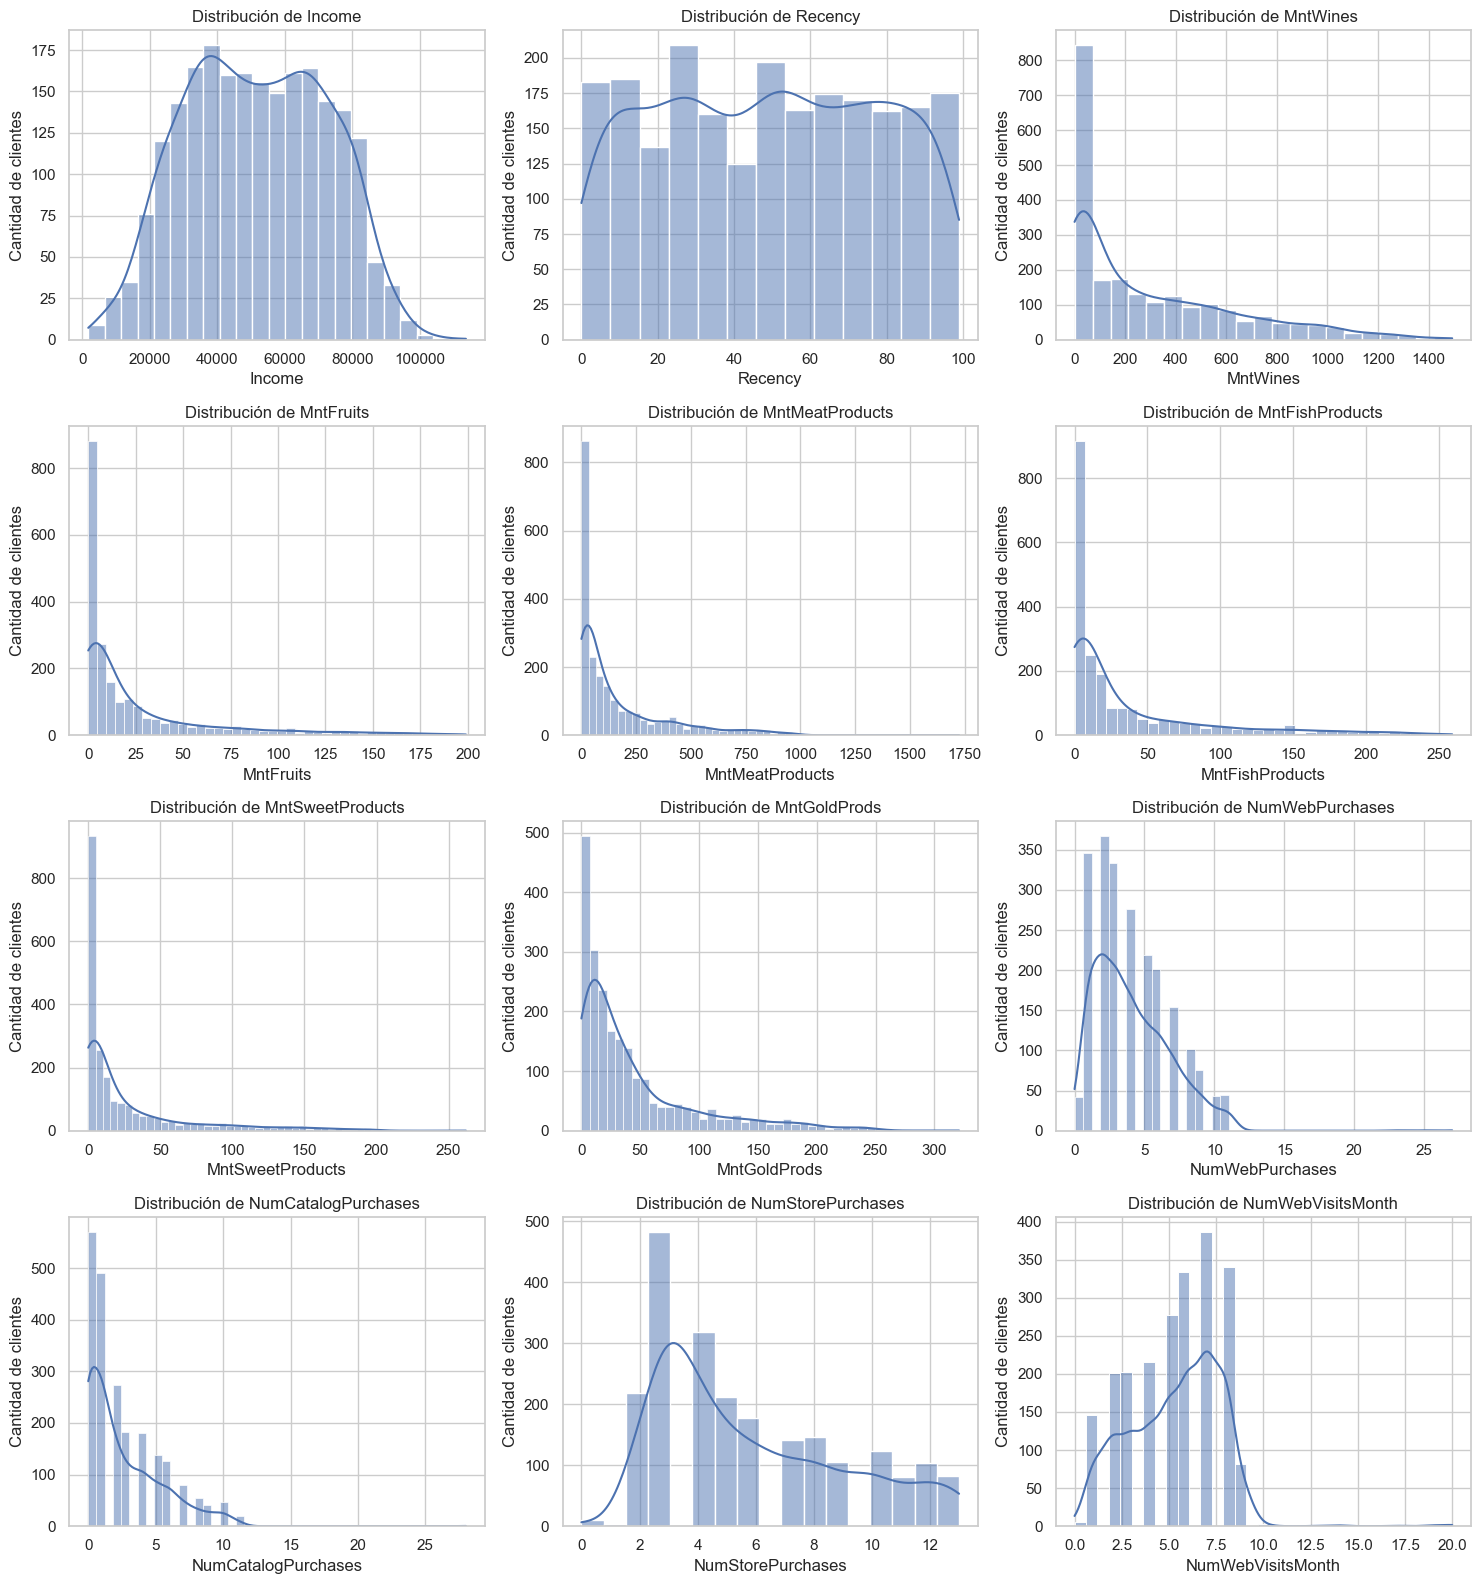

In [8]:
important_cols = [
    "Income",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

# Filtrar solo las que existen
important_cols = [col for col in important_cols if col in df_clean.columns]

# Número de columnas que quieres en la grilla
cols = 3  

# Número de filas necesarias automáticamente
rows = math.ceil(len(important_cols) / cols)

# Crear una sola figura con subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))

# Aplanar la matriz de ejes para iterar fácilmente
axes = axes.flatten()

# Graficar cada variable en su subplot
for i, col in enumerate(important_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Cantidad de clientes")

# Eliminar subplots vacíos (si sobran espacios)
for j in range(len(important_cols), len(axes)):
    fig.delaxes(axes[j])

# Ajustar espacios
plt.tight_layout()

# Mostrar todo en UNA sola imagen
plt.show()

El análisis exploratorio de las variables numéricas evidencia distintos comportamientos distribucionales dentro del conjunto de datos. La variable *Income* presenta una distribución aproximadamente normal, lo que indica una concentración equilibrada de los ingresos sin presencia significativa de valores atípicos, haciéndola adecuada para métodos estadísticos paramétricos. Por su parte, *Recency* muestra una distribución cercana a uniforme, sugiriendo una dispersión homogénea en el tiempo desde la última compra y una limitada capacidad discriminativa de manera individual. En contraste, las variables de gasto (*MntWines*, *MntFruits*, *MntMeatProducts*, entre otras) exhiben una marcada asimetría positiva, con alta concentración de valores bajos y una cola larga de valores elevados, lo que evidencia la presencia de outliers y una alta variabilidad en el comportamiento de consumo. De forma similar, las variables de frecuencia de compra (*NumWebPurchases*, *NumCatalogPurchases*) corresponden a datos discretos con sesgo a la derecha, mientras que *NumStorePurchases* presenta una distribución más centrada y estable. Finalmente, *NumWebVisitsMonth* muestra una distribución unimodal con ligera asimetría, lo que sugiere un comportamiento moderadamente concentrado en valores medios. En conjunto, estos patrones indican la necesidad de aplicar transformaciones en variables sesgadas, así como técnicas robustas de análisis, debido a la heterogeneidad y no normalidad predominante en el dataset.


### Detección visual de outliers con boxplots
 Los boxplots permiten ver valores extremos de forma rápida. Un outlier no siempre es un error: puede ser un cliente VIP o un caso raro.

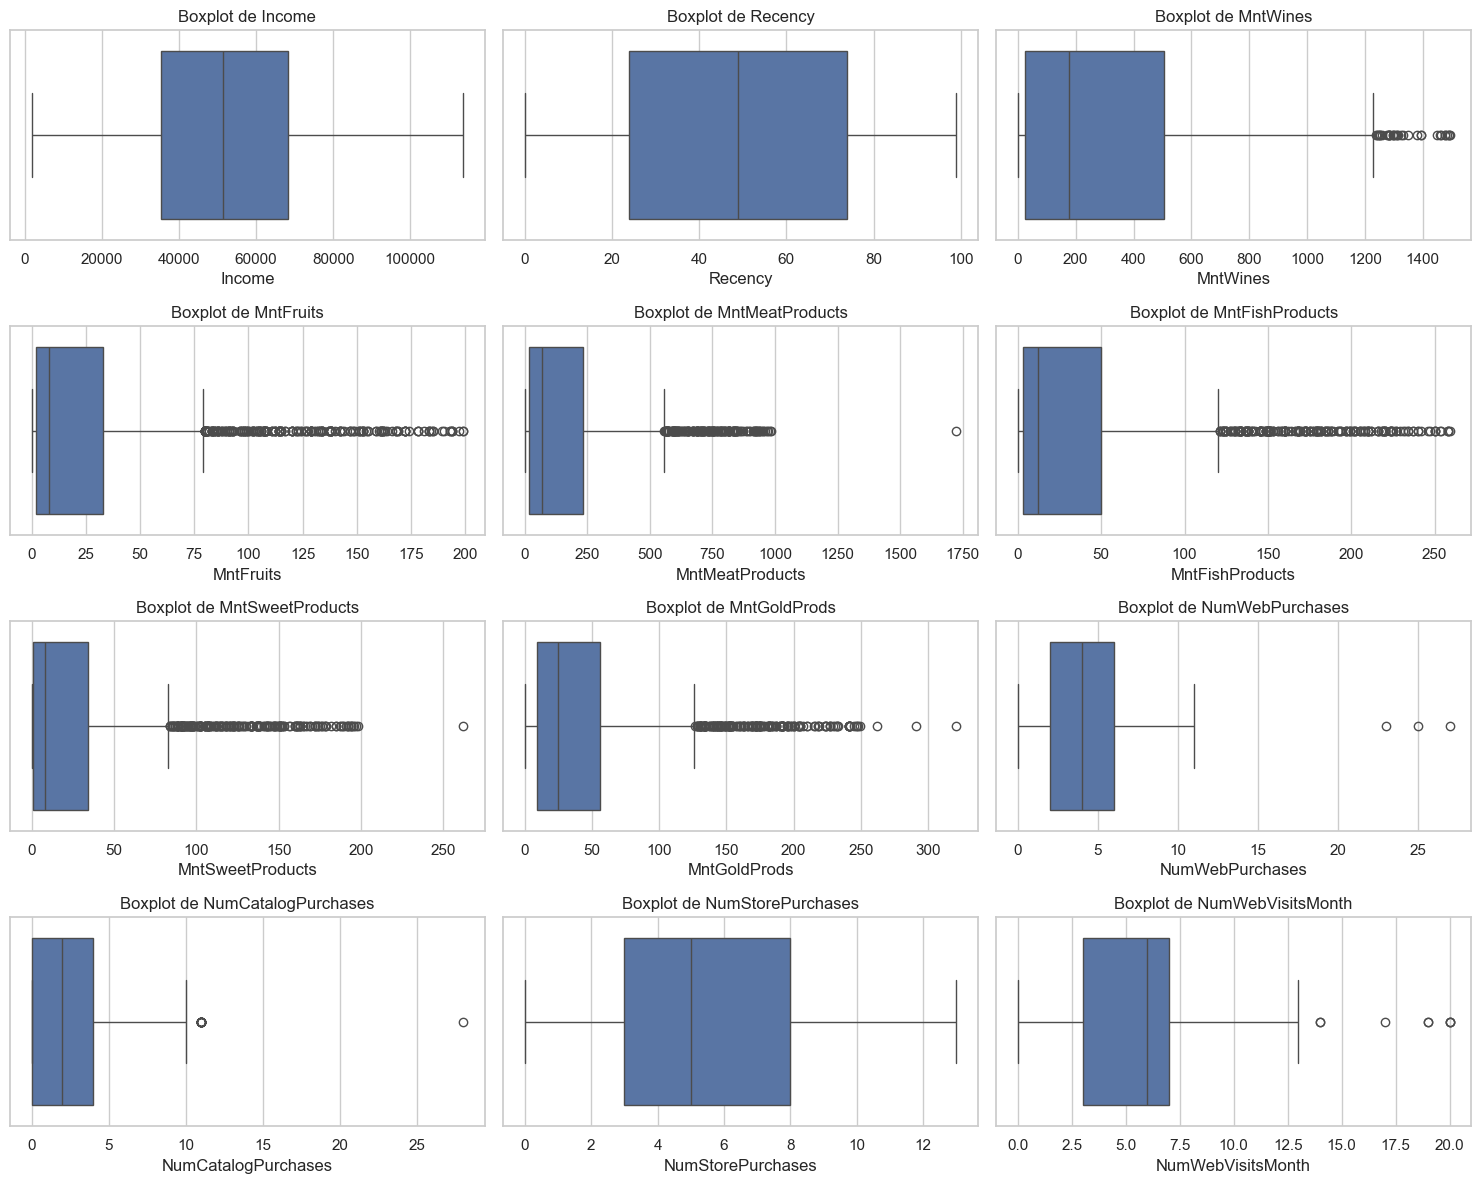

In [9]:
# Número de columnas en la grilla
cols = 3

# Calcular número de filas necesarias
rows = math.ceil(len(important_cols) / cols)

# Crear figura con subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))

# Aplanar ejes para iterar fácil
axes = axes.flatten()

# Graficar cada boxplot
for i, col in enumerate(important_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)

# Eliminar espacios vacíos
for j in range(len(important_cols), len(axes)):
    fig.delaxes(axes[j])

# Ajustar layout
plt.tight_layout()

# Mostrar todo en una sola imagen
plt.show()

### INTERPRETACIÓN:
El análisis de los diagramas de caja evidencia diferencias importantes en la dispersión, simetría y presencia de valores atípicos entre las variables. *Income* presenta una distribución relativamente simétrica, con una mediana centrada y sin una cantidad significativa de outliers, lo que confirma su estabilidad y coherencia con una distribución aproximadamente normal. De manera similar, *Recency* muestra una dispersión amplia pero equilibrada, sin sesgos marcados ni valores extremos relevantes. En contraste, las variables de gasto (*MntWines*, *MntFruits*, *MntMeatProducts*, *MntFishProducts*, *MntSweetProducts* y *MntGoldProds*) exhiben una marcada asimetría positiva, evidenciada por cajas concentradas en valores bajos, bigotes extendidos hacia la derecha y una alta presencia de outliers superiores, lo que indica una fuerte heterogeneidad en el comportamiento de consumo y la existencia de pocos individuos con niveles de gasto significativamente altos. Por su parte, las variables de frecuencia de compra (*NumWebPurchases* y *NumCatalogPurchases*) también presentan sesgo a la derecha y algunos valores atípicos, característicos de datos de conteo con baja frecuencia en la mayoría de observaciones. En contraste, *NumStorePurchases* muestra una distribución más compacta y centrada, con menor variabilidad relativa y ausencia de outliers extremos, lo que sugiere un comportamiento más consistente. Finalmente, *NumWebVisitsMonth* presenta ligera asimetría positiva con algunos valores atípicos altos, indicando variabilidad moderada en la interacción digital. En conjunto, los boxplots confirman la predominancia de distribuciones no normales, la presencia de valores atípicos y la necesidad de aplicar transformaciones o métodos robustos para un análisis estadístico más preciso.



###  Matriz de correlación


Calculamos la correlación entre variables numéricas. La correlación mide si dos variables se mueven juntas.

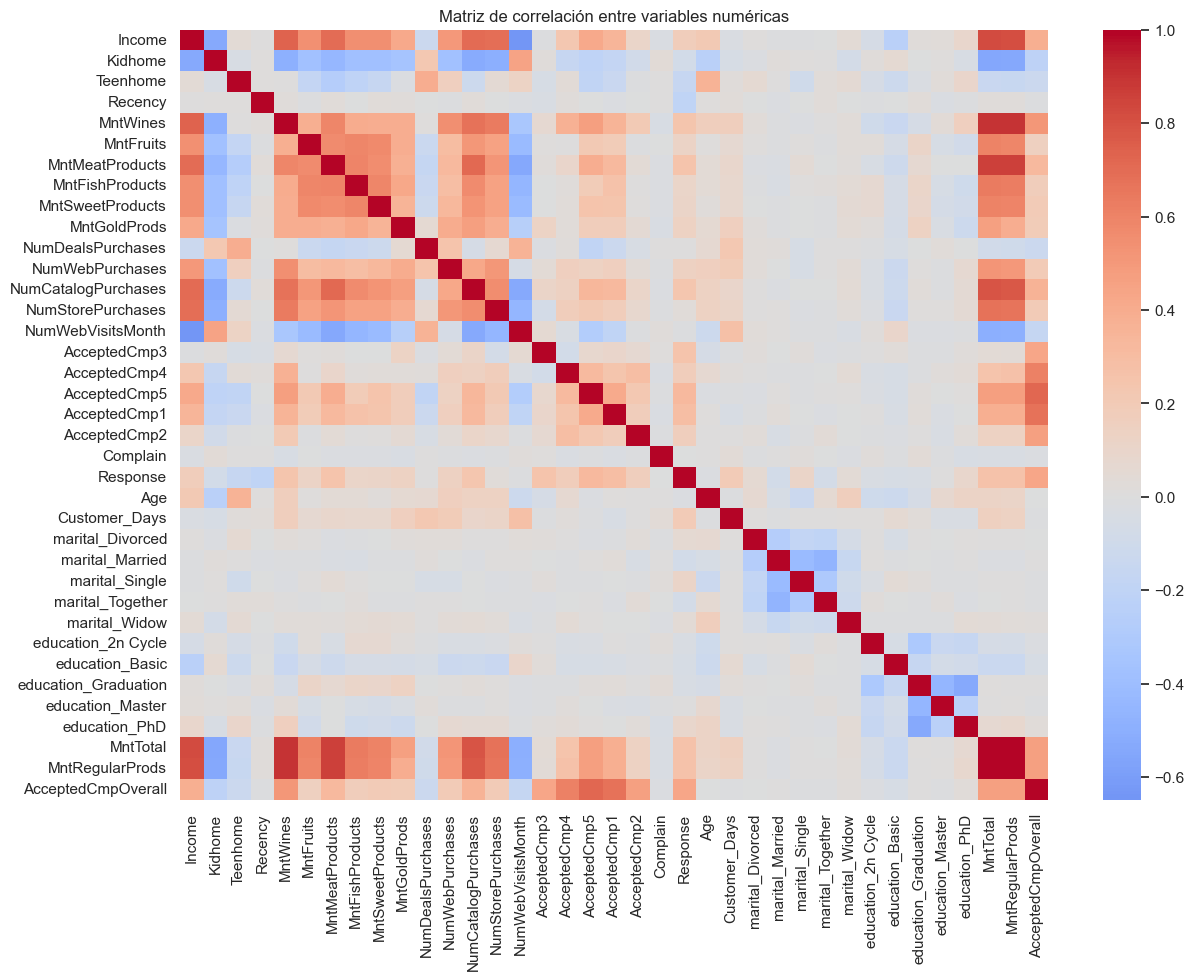

In [11]:
numeric_cols_clean = df_clean.select_dtypes(include=["int64", "float64"]).columns
corr_matrix = df_clean[numeric_cols_clean].corr()

# Visualizamos la matriz de correlación con un heatmap.
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

Si MntWines y MntMeatProducts tienen alta correlación, puede existir una tribu de clientes que compran productos premium en varias categorías.

Si NumWebVisitsMonth tiene baja relación con compras, podría haber clientes que navegan mucho pero compran poco. Eso es útil para campañas de conversión.

In [12]:
df_clean


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014.0,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245.0,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0


En la etapa de exploración y limpieza se revisó la estructura general del dataset iFood Marketing Data, compuesto por clientes y variables asociadas a ingresos, recencia, gasto por categoría de producto, frecuencia de compra y canales de compra. Se identificaron valores nulos y se trataron mediante imputación con la mediana en variables numéricas, evitando perder registros de clientes. También se eliminaron columnas sin valor analítico, como variables constantes o posibles identificadores, ya que no contribuyen a diferenciar patrones de comportamiento.

El análisis de distribuciones mostró que varias variables de gasto presentan sesgo a la derecha, lo cual es esperable en datos comerciales: muchos clientes compran poco y pocos clientes concentran altos niveles de consumo. Estos valores extremos no se eliminaron automáticamente porque pueden representar clientes de alto valor para el negocio. Esta base limpia queda preparada para el laboratorio de escalamiento, donde se evaluará cómo la escala de las variables afecta los resultados de clustering.

## FASE 2: LABORATORIO DE ESCALAMIENTO.

 Creamos una lista de variables candidatas. Elegimos variables que representan comportamiento real del cliente:
 ingresos, recencia, gasto por categoría y canales de compra.

In [13]:
candidate_features = [
    "Income",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

# Algunos archivos del dataset pueden traer variables derivadas adicionales.
# Si existen, también pueden aportar valor para segmentar clientes.
optional_features = [
    "Age",
    "Customer_Days",
    "MntTotal",
    "MntRegularProds"
]

# Unimos las variables principales con las opcionales.
candidate_features = candidate_features + optional_features

# Filtramos la lista para quedarnos solo con columnas que existan realmente en df_clean.
# Esto evita errores si alguna columna no aparece con ese nombre exacto.
features = [col for col in candidate_features if col in df_clean.columns]

# Creamos el dataset que usaremos para clustering.
# Cada fila representa un cliente y cada columna una característica numérica útil.
X = df_clean[features].copy()

# Mostramos las variables seleccionadas.
print("Variables usadas para clustering:")
print(features)

# Mostramos el tamaño del dataset de modelado.
print("\nDimensiones de X:")
print(X.shape)

# Revisamos las primeras filas para confirmar que todo sea numérico y tenga sentido.
X.head()

Variables usadas para clustering:
['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Customer_Days', 'MntTotal', 'MntRegularProds']

Dimensiones de X:
(2205, 17)


,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Customer_Days,MntTotal,MntRegularProds
0,58138.0,58,635,88,546,172,88,88,3,8,10,4,7,63,2822,1529,1441
1,46344.0,38,11,1,6,2,1,6,2,1,1,2,5,66,2272,21,15
2,71613.0,26,426,49,127,111,21,42,1,8,2,10,4,55,2471,734,692
3,26646.0,26,11,4,20,10,3,5,2,2,0,4,6,36,2298,48,43
4,58293.0,94,173,43,118,46,27,15,5,5,3,6,5,39,2320,407,392


In [14]:
# Calculamos estadísticas descriptivas solo para las variables seleccionadas.
# Esto nos ayuda a ver si unas variables tienen rangos mucho más grandes que otras.
scale_summary = X.describe().T

# Agregamos una columna con el rango: máximo - mínimo.
# El rango nos muestra qué tan amplia es la escala de cada variable.
scale_summary["range"] = scale_summary["max"] - scale_summary["min"]

# Ordenamos por rango de mayor a menor.
# Así identificamos qué variables podrían dominar el cálculo de distancia.
scale_summary = scale_summary.sort_values("range", ascending=False)

# Mostramos el resumen.
scale_summary

,count,mean,std,min,25%,50%,75%,max,range
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0,112004.0
MntRegularProds,2205.0,518.707483,553.847248,-283.0,42.0,288.0,884.0,2458.0,2741.0
MntTotal,2205.0,562.764626,575.936911,4.0,56.0,343.0,964.0,2491.0,2487.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0,1725.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0,1493.0
Customer_Days,2205.0,2512.718367,202.563647,2159.0,2339.0,2515.0,2688.0,2858.0,699.0
MntGoldProds,2205.0,44.057143,51.736211,0.0,9.0,25.0,56.0,321.0,321.0
MntSweetProducts,2205.0,27.128345,41.130468,0.0,1.0,8.0,34.0,262.0,262.0
MntFishProducts,2205.0,37.756463,54.824635,0.0,3.0,12.0,50.0,259.0,259.0
MntFruits,2205.0,26.403175,39.784484,0.0,2.0,8.0,33.0,199.0,199.0


In [15]:
# Escenario A: datos crudos.
# Aquí usamos las variables tal como vienen en la base.
X_raw = X.copy()

# Escenario B: StandardScaler.
# Convierte las variables a media 0 y desviación estándar 1.
# Es muy usado en clustering porque iguala la importancia estadística de las variables.
standard_scaler = StandardScaler()
X_standard = standard_scaler.fit_transform(X)

# Convertimos el resultado a DataFrame para conservar nombres de columnas.
X_standard = pd.DataFrame(X_standard, columns=features, index=X.index)

# Escenario C: MinMaxScaler.
# Convierte cada variable a un rango entre 0 y 1.
# Es útil cuando queremos mantener todos los valores dentro de un intervalo común.
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

# Convertimos el resultado a DataFrame para conservar nombres de columnas.
X_minmax = pd.DataFrame(X_minmax, columns=features, index=X.index)

# Validamos visualmente las escalas después de las transformaciones.
print("Rangos en datos crudos:")
print(X_raw.agg(["min", "max"]).T.head())

print("\nRangos con StandardScaler:")
print(X_standard.agg(["mean", "std"]).T.head())

print("\nRangos con MinMaxScaler:")
print(X_minmax.agg(["min", "max"]).T.head())

Rangos en datos crudos:
                    min       max
Income           1730.0  113734.0
Recency             0.0      99.0
MntWines            0.0    1493.0
MntFruits           0.0     199.0
MntMeatProducts     0.0    1725.0

Rangos con StandardScaler:
                         mean       std
Income           2.255691e-17  1.000227
Recency          7.975480e-17  1.000227
MntWines        -2.416812e-17  1.000227
MntFruits        2.175131e-17  1.000227
MntMeatProducts  1.611208e-18  1.000227

Rangos con MinMaxScaler:
                 min  max
Income           0.0  1.0
Recency          0.0  1.0
MntWines         0.0  1.0
MntFruits        0.0  1.0
MntMeatProducts  0.0  1.0


# 5. Función auxiliar para correr K-Means
   Esta función entrena K-Means sobre una versión del dataset y devuelve métricas útiles para comparar escenarios.
    
    Parámetros:
    
    X_data: dataset numérico, escalado o no escalado.
    scenario_name: nombre del escenario para identificar resultados.
    k: número provisional de clusters.

In [16]:
def run_kmeans_experiment(X_data, scenario_name, k=4):
     # Creamos el modelo K-Means.
    # n_clusters define cuántos grupos queremos encontrar.
    # n_init=10 hace que K-Means pruebe varias inicializaciones y se quede con la mejor.
    # random_state garantiza reproducibilidad.
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    # Entrenamos el modelo y asignamos un cluster a cada cliente.
    labels = kmeans.fit_predict(X_data)

    # Calculamos el score de silueta.
    # Este score evalúa qué tan bien separado está cada cliente de otros clusters.
    silhouette = silhouette_score(X_data, labels)

    # Guardamos la inercia.
    # La inercia mide qué tan cerca están los puntos de sus centroides.
    # Menor inercia significa clusters más compactos, pero solo se compara dentro de la misma escala.
    inertia = kmeans.inertia_

    # Contamos cuántos clientes quedaron en cada cluster.
    # Esto ayuda a detectar si un escenario produce clusters demasiado desbalanceados.
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    # Devolvemos los resultados en un diccionario.
    return {
        "scenario": scenario_name,
        "model": kmeans,
        "labels": labels,
        "silhouette": silhouette,
        "inertia": inertia,
        "cluster_sizes": cluster_sizes
    }


In [17]:
# Definimos un K provisional para comparar escenarios.
k_provisional = 4

# Corremos K-Means con datos crudos.
result_raw = run_kmeans_experiment(
    X_data=X_raw,
    scenario_name="Datos crudos",
    k=k_provisional
)

# Corremos K-Means con StandardScaler.
result_standard = run_kmeans_experiment(
    X_data=X_standard,
    scenario_name="StandardScaler",
    k=k_provisional
)

# Corremos K-Means con MinMaxScaler.
result_minmax = run_kmeans_experiment(
    X_data=X_minmax,
    scenario_name="MinMaxScaler",
    k=k_provisional
)

# Guardamos todos los resultados en una lista.
results = [result_raw, result_standard, result_minmax]

# Creamos una tabla comparativa con las métricas principales.
comparison_table = pd.DataFrame({
    "Escenario": [r["scenario"] for r in results],
    "Score_Silueta": [r["silhouette"] for r in results],
    "Inercia": [r["inertia"] for r in results]
})

# Mostramos la tabla ordenada por Score de Silueta.
# El mayor score de silueta suele ser mejor.
comparison_table.sort_values("Score_Silueta", ascending=False)

,Escenario,Score_Silueta,Inercia
0,Datos crudos,0.533517,8.148632e+10
1,StandardScaler,0.207105,1.966899e+04
2,MinMaxScaler,0.152273,7.962525e+02


El Score de Silueta mide si los clientes están bien asignados a su cluster.

Valores aproximados:

-Cerca de 1	Clusters muy bien separados

-Cerca de 0	Clusters se mezclan

-Menor que 0	Posibles asignaciones incorrectas

Se compararon tres escenarios de escalamiento. Los datos crudos obtuvieron el mayor Score de Silueta, con 0.5335; sin embargo, este resultado puede estar dominado por variables de gran escala como ingresos y montos de compra.

Entre los escenarios escalados, StandardScaler obtuvo mejor desempeño que MinMaxScaler, con un Score de Silueta de 0.2071 frente a 0.1523. Por esta razón, se seleccionó StandardScaler para continuar el proyecto, ya que permite comparar variables en distintas unidades y facilita interpretar los centroides como valores por encima o por debajo del promedio.

In [18]:
# Creamos una tabla vacía para guardar tamaños de clusters.
cluster_size_table = pd.DataFrame()

# Recorremos cada resultado y agregamos los tamaños de cluster.
for r in results:
    cluster_size_table[r["scenario"]] = r["cluster_sizes"]

# Reemplazamos valores faltantes por 0. Esto puede ocurrir si algún escenario no genera todos los clusters esperados.
cluster_size_table = cluster_size_table.fillna(0).astype(int)

cluster_size_table

,Datos crudos,StandardScaler,MinMaxScaler
0,505,968,535
1,642,464,615
2,612,435,597
3,446,338,458


### Función para visualizar clusters en 2D usando PCA
Esta función reduce los datos a 2 dimensiones usando PCA y grafica los clusters con colores diferentes.
    
No usamos PCA para entrenar K-Means aquí. Lo usamos solo para visualizar.

K-Means (Datos crudos) → Varianza explicada: 99.98%
K-Means (StandardScaler) → Varianza explicada: 56.28%
K-Means (MinMaxScaler) → Varianza explicada: 55.71%


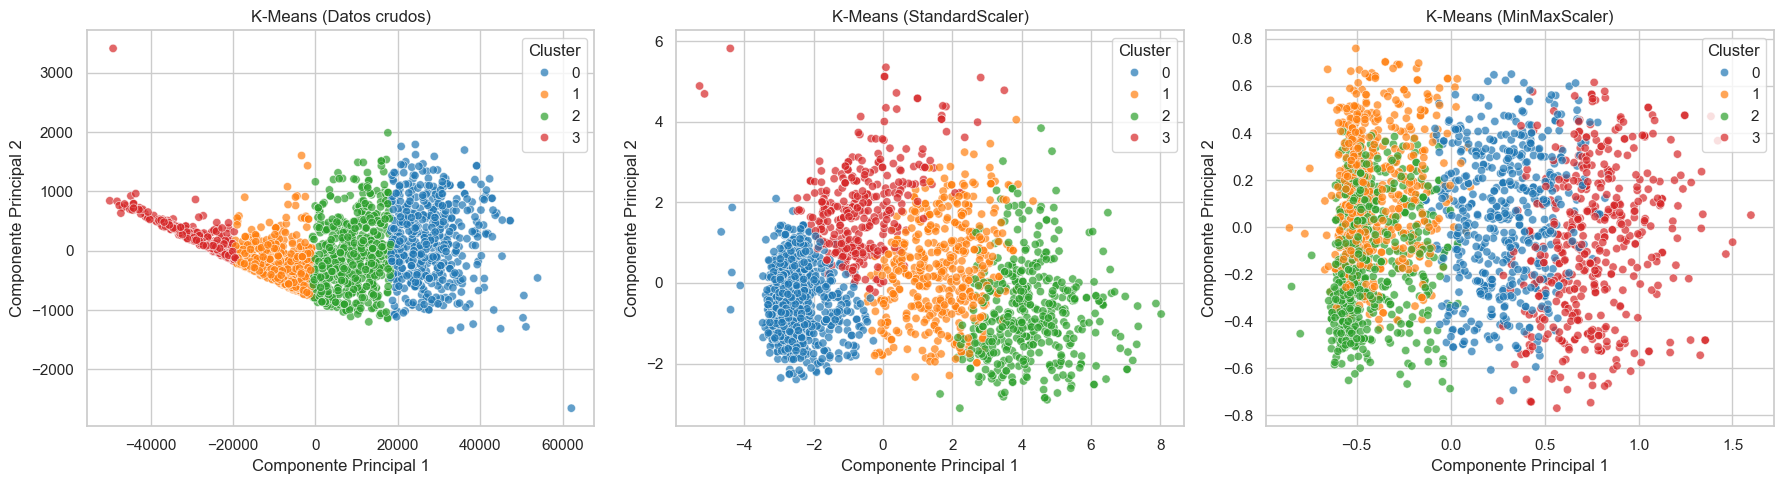

In [19]:
def plot_clusters_pca(X_data, labels, title, ax):
    
    # PCA a 2 componentes
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_data)

    # DataFrame para graficar
    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "Cluster": labels
    })

    # Graficar en el eje recibido (NO crear nueva figura)
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="Cluster",
        palette="tab10",
        alpha=0.7,
        ax=ax
    )

    # Títulos y etiquetas
    ax.set_title(title)
    ax.set_xlabel("Componente Principal 1")
    ax.set_ylabel("Componente Principal 2")

    # Varianza explicada
    explained_variance = pca.explained_variance_ratio_.sum()
    print(f"{title} → Varianza explicada: {explained_variance:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_clusters_pca(
    X_data=X_raw,
    labels=result_raw["labels"],
    title="K-Means (Datos crudos)",
    ax=axes[0]
)

plot_clusters_pca(
    X_data=X_standard,
    labels=result_standard["labels"],
    title="K-Means (StandardScaler)",
    ax=axes[1]
)

plot_clusters_pca(
    X_data=X_minmax,
    labels=result_minmax["labels"],
    title="K-Means (MinMaxScaler)",
    ax=axes[2]
)

plt.tight_layout()
plt.show()


La proyección de los clusters mediante PCA evidencia un impacto significativo del escalado en la estructura y separabilidad de los grupos generados por K-Means. En el caso de los datos crudos, se observa una separación artificial dominada por la magnitud de las variables, donde los clusters se organizan principalmente a lo largo del primer componente principal, indicando que variables con mayor escala (como ingresos o montos de gasto) están sesgando la formación de grupos. Al aplicar *StandardScaler*, la distribución de los datos se centra y estandariza, lo que permite una separación más equilibrada y compacta de los clusters, reduciendo la influencia de las escalas originales y facilitando la identificación de patrones estructurales más consistentes entre observaciones. Por otro lado, con *MinMaxScaler*, aunque los datos se restringen a un rango uniforme, se observa mayor solapamiento entre clusters, lo que sugiere una menor capacidad de discriminación en comparación con la estandarización. En conjunto, estos resultados indican que el uso de escalado, particularmente mediante estandarización, es fundamental para mejorar la calidad de los agrupamientos en K-Means, ya que favorece la formación de clusters más definidos y representativos de la estructura subyacente de los datos.


## COMPARACIÓN DE CENTROIDES.

In [20]:
def get_centroids_dataframe(model, features, scenario_name):
    """
    Esta función convierte los centroides de K-Means en un DataFrame.
    Así podemos ver el perfil promedio de cada cluster.
    """

    # Extraemos los centroides del modelo.
    centroids = model.cluster_centers_

    # Convertimos los centroides a DataFrame.
    centroids_df = pd.DataFrame(
        centroids,
        columns=features
    )

    # Agregamos una columna para identificar el cluster.
    centroids_df["Cluster"] = centroids_df.index

    # Agregamos el nombre del escenario.
    centroids_df["Escenario"] = scenario_name

    return centroids_df


# Obtenemos centroides para cada escenario.
centroids_raw = get_centroids_dataframe(
    result_raw["model"],
    features,
    "Datos crudos"
)

centroids_standard = get_centroids_dataframe(
    result_standard["model"],
    features,
    "StandardScaler"
)

centroids_minmax = get_centroids_dataframe(
    result_minmax["model"],
    features,
    "MinMaxScaler"
)

# Mostramos centroides de datos crudos.
# Estos estarán en las unidades originales.
centroids_raw

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Customer_Days,MntTotal,MntRegularProds,Cluster,Escenario
0,79243.243564,49.746535,647.635644,62.796040,441.481188,91.021782,68.221782,74.500990,1.356436,5.324752,5.742574,8.443564,2.867327,52.180198,2497.798020,1311.156436,1236.655446,0,Datos crudos
1,41246.848910,48.492212,109.615265,7.872274,44.500000,13.034268,8.029595,25.856698,2.646417,3.174455,1.048287,4.049844,6.403427,51.042056,2502.665109,183.051402,157.194704,1,Datos crudos
2,60455.445351,48.924959,440.869494,30.993475,169.164763,41.324633,28.778140,58.194127,2.969005,5.628059,3.355628,7.657423,4.980424,54.386623,2528.492659,711.130506,652.936378,2,Datos crudos
3,23076.889888,49.033708,16.653933,5.514607,20.894382,8.060674,5.775281,16.292135,2.040449,1.943820,0.456180,2.883146,7.092135,45.408989,2522.424719,56.898876,40.606742,3,Datos crudos


En los datos crudos, los centroides estarán en unidades reales:

Income en dinero.

Recency en días.

MntWines en gasto.

NumWebPurchases en número de compras.

Pero en StandardScaler y MinMaxScaler, los centroides ya están transformados. Sirven para comparar patrones relativos, no valores reales de negocio.

## Heatmap de centroides para StandardScaler y MinMaxScaler

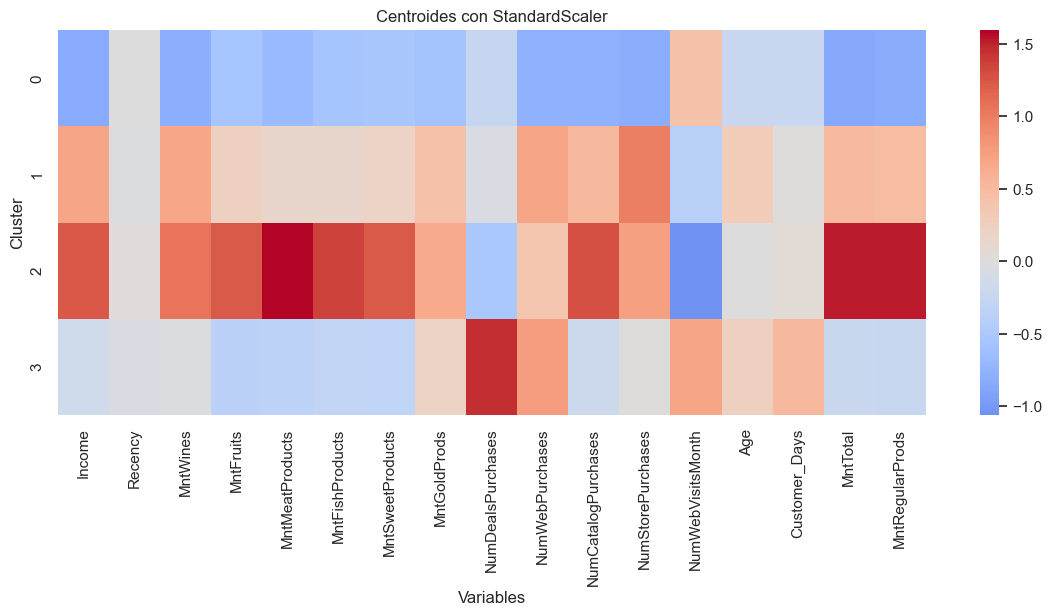

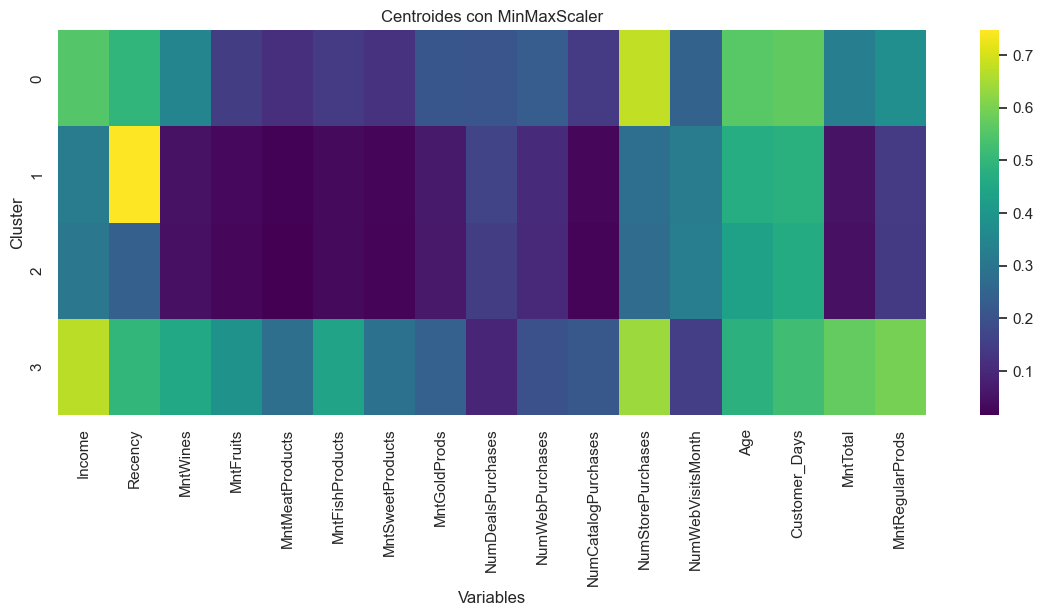

In [21]:
plt.figure(figsize=(14, 5))
sns.heatmap(
    centroids_standard.drop(columns=["Cluster", "Escenario"]),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Centroides con StandardScaler")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.show()


plt.figure(figsize=(14, 5))
sns.heatmap(
    centroids_minmax.drop(columns=["Cluster", "Escenario"]),
    cmap="viridis",
    annot=False
)
plt.title("Centroides con MinMaxScaler")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.show()

## Conclusión del laboratorio de escalamiento

Se comparó el desempeño de K-Means con tres versiones del dataset: datos crudos, datos transformados con StandardScaler y datos transformados con MinMaxScaler. El escenario con datos crudos obtuvo el mayor Score de Silueta, con un valor de 0.5335. Sin embargo, este resultado debe interpretarse con cautela, ya que K-Means utiliza distancias y las variables con mayor escala, como ingresos y montos de compra, pueden dominar el agrupamiento.

Desde una perspectiva de negocio, usar los datos crudos podría llevar a construir tribus basadas principalmente en poder adquisitivo o gasto total, dejando en segundo plano variables importantes como recencia, frecuencia de compra, canales de compra y visitas web. Por esta razón, aunque la silueta de los datos crudos es mayor, no se considera la mejor opción metodológica para continuar el proyecto.

Entre los escenarios escalados, StandardScaler obtuvo un Score de Silueta de 0.2071, superior al resultado de MinMaxScaler, que fue 0.1523. Además, StandardScaler permite interpretar los centroides en términos de desviaciones respecto al promedio, lo cual facilita el perfilamiento posterior de las tribus.

Por lo tanto, se selecciona StandardScaler como método de escalamiento para el resto del proyecto, ya que ofrece un balance adecuado entre rigor técnico, comparabilidad entre variables y utilidad interpretativa para la estrategia de marketing.

### ESCALADOR ELEGIDO

In [22]:

# Según el laboratorio, se elige StandardScaler para continuar.
X_scaled = X_standard.copy()
selected_scaler = standard_scaler

print("Dataset escalado final:")
print(X_scaled.shape)

display(X_scaled.head())

Dataset escalado final:
(2205, 17)


,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Customer_Days,MntTotal,MntRegularProds
0,0.314651,0.310830,0.974566,1.548614,1.748400,2.449154,1.480301,0.849556,0.361479,1.424772,2.628526,-0.562650,0.689203,1.017189,1.527183,1.678056,1.665625
1,-0.254877,-0.380600,-0.874776,-0.638664,-0.731678,-0.652345,-0.635399,-0.735767,-0.168834,-1.132957,-0.588043,-1.179732,-0.139645,1.273530,-1.188629,-0.940880,-0.909676
2,0.965354,-0.795458,0.355155,0.568110,-0.175957,1.336263,-0.149031,-0.039771,-0.699147,1.424772,-0.230646,1.288596,-0.554069,0.333612,-0.205999,0.297384,0.312960
3,-1.206087,-0.795458,-0.874776,-0.563241,-0.667380,-0.506392,-0.586763,-0.755100,-0.168834,-0.767567,-0.945440,-0.562650,0.274779,-1.289883,-1.060245,-0.893989,-0.859109
4,0.322136,1.555404,-0.394659,0.417263,-0.217292,0.150396,-0.003121,-0.561768,1.422105,0.328602,0.126750,0.054432,-0.139645,-1.033542,-0.951612,-0.270516,-0.228829


### K-MEANS: MÉTODO DEL CODO Y SCORE DE SILUETA

,K,Inercia,Score_Silueta
0,2,23815.364772,0.351900
1,3,20811.908218,0.248900
2,4,19668.990217,0.207105
3,5,18780.431020,0.117886
4,6,17904.735572,0.118254
5,7,17223.762521,0.120753
6,8,16726.480172,0.112770
7,9,16253.826853,0.112260
8,10,15875.022238,0.114110


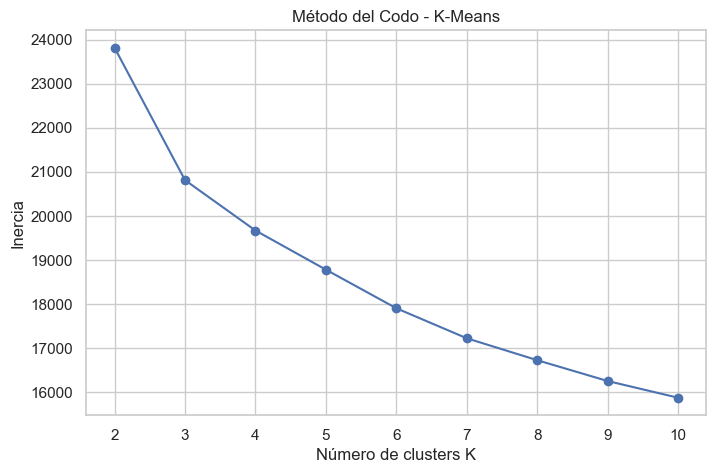

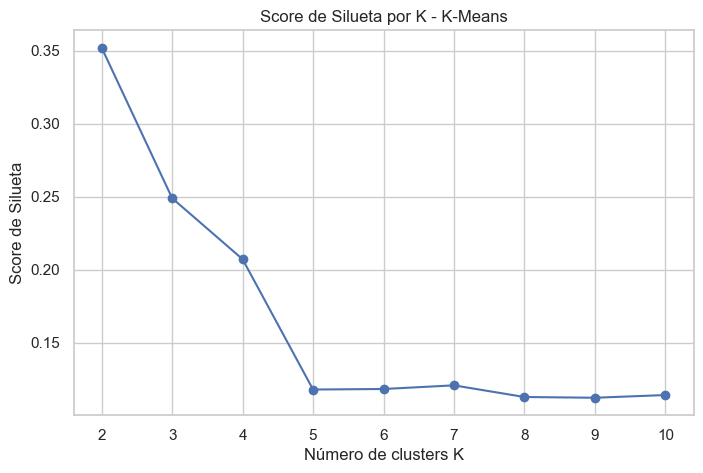

In [23]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )
    
    labels = model.fit_predict(X_scaled)
    
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

kmeans_eval = pd.DataFrame({
    "K": list(k_values),
    "Inercia": inertias,
    "Score_Silueta": silhouette_scores
})

display(kmeans_eval)

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval["K"], kmeans_eval["Inercia"], marker="o")
plt.title("Método del Codo - K-Means")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval["K"], kmeans_eval["Score_Silueta"], marker="o")
plt.title("Score de Silueta por K - K-Means")
plt.xlabel("Número de clusters K")
plt.ylabel("Score de Silueta")
plt.grid(True)
plt.show()

In [24]:
kmeans_business_eval = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )
    
    labels = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    sizes = pd.Series(labels).value_counts().sort_index()
    
    kmeans_business_eval.append({
        "K": k,
        "Score_Silueta": sil,
        "Cluster_mas_pequeno": sizes.min(),
        "Porcentaje_cluster_mas_pequeno": sizes.min() / len(labels) * 100,
        "Tamanos_clusters": sizes.to_dict()
    })

kmeans_business_eval = pd.DataFrame(kmeans_business_eval)

display(kmeans_business_eval)

,K,Score_Silueta,Cluster_mas_pequeno,Porcentaje_cluster_mas_pequeno,Tamanos_clusters
0,2,0.351900,865,39.229025,"{0: 865, 1: 1340}"
1,3,0.248900,569,25.804989,"{0: 1024, 1: 569, 2: 612}"
2,4,0.207105,338,15.328798,"{0: 968, 1: 464, 2: 435, 3: 338}"
3,5,0.117886,332,15.056689,"{0: 525, 1: 416, 2: 447, 3: 332, 4: 485}"
4,6,0.118254,254,11.519274,"{0: 273, 1: 475, 2: 303, 3: 254, 4: 375, 5: 525}"


In [25]:
# Se elige K = 3 por balance entre score, tamaños e interpretabilidad comercial.
k_chosen = 3

kmeans_final = KMeans(
    n_clusters=k_chosen,
    n_init=10,
    random_state=RANDOM_STATE
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

kmeans_cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()

print("K-Means final")
print("K elegido:", k_chosen)
print("Score de Silueta:", round(kmeans_silhouette, 4))
print("\nTamaño de clusters:")
print(kmeans_cluster_sizes)

K-Means final
K elegido: 3
Score de Silueta: 0.2489

Tamaño de clusters:
0    1024
1     569
2     612
Name: count, dtype: int64


### CLUSTERING JERÁRQUICO: DENDROGRAMA

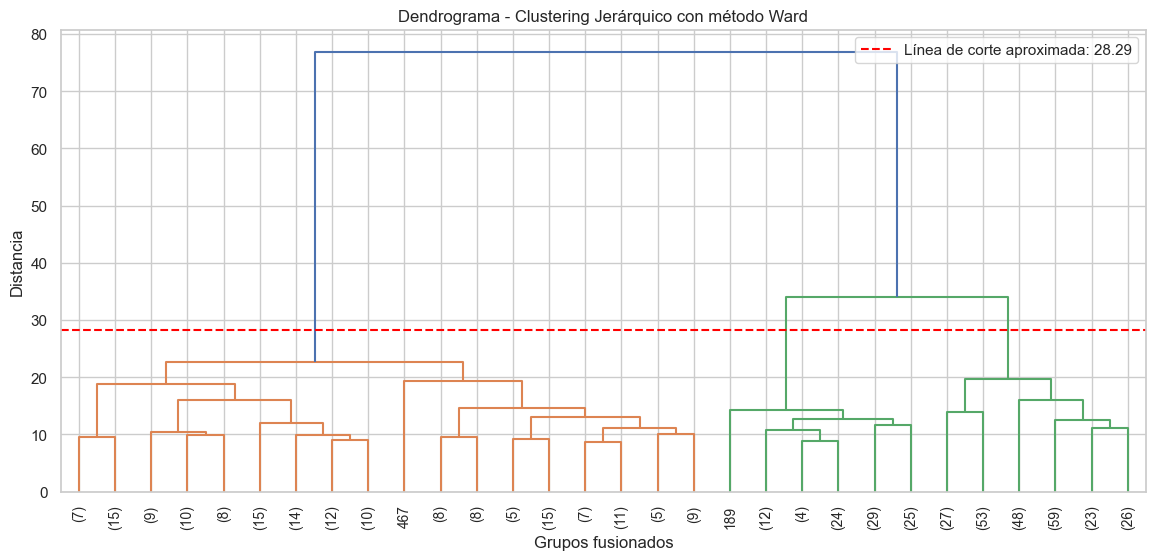

In [26]:
import scipy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
sample_size = min(500, X_scaled.shape[0])

X_sample = X_scaled.sample(
    n=sample_size,
    random_state=RANDOM_STATE
)

Z = linkage(
    X_sample,
    method="ward"
)

# Línea de corte aproximada para 3 clusters.
cut_height = (Z[-3, 2] + Z[-2, 2]) / 2

plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.axhline(
    y=cut_height,
    color="red",
    linestyle="--",
    label=f"Línea de corte aproximada: {cut_height:.2f}"
)

plt.title("Dendrograma - Clustering Jerárquico con método Ward")
plt.xlabel("Grupos fusionados")
plt.ylabel("Distancia")
plt.legend()
plt.show()

### CLUSTERING JERÁRQUICO CON 3 CLUSTERS

In [27]:

from sklearn.cluster import AgglomerativeClustering

hierarchical_n_clusters = 3

hierarchical_model = AgglomerativeClustering(
    n_clusters=hierarchical_n_clusters,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_cluster_sizes = pd.Series(
    hierarchical_labels
).value_counts().sort_index()

print("Clustering Jerárquico")
print("Número de clusters:", hierarchical_n_clusters)
print("Score de Silueta:", round(hierarchical_silhouette, 4))
print("\nTamaño de clusters:")
print(hierarchical_cluster_sizes)

Clustering Jerárquico
Número de clusters: 3
Score de Silueta: 0.2251

Tamaño de clusters:
0    581
1    652
2    972
Name: count, dtype: int64


### DBSCAN: GRÁFICO DE K-DISTANCIAS

Número de variables: 17
min_samples elegido: 20


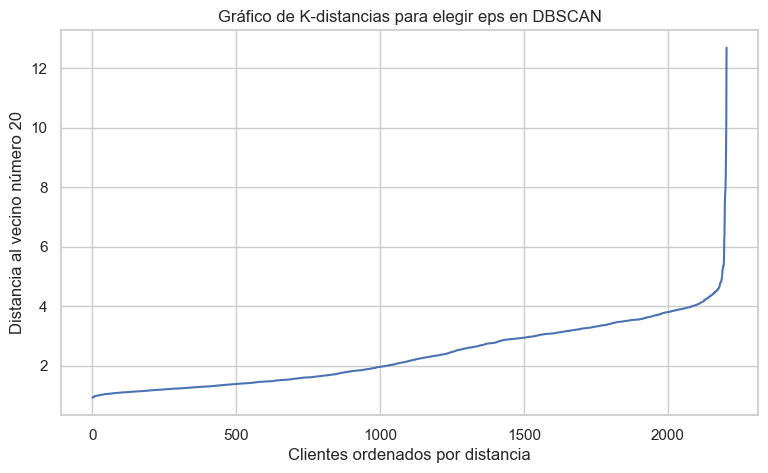

In [28]:
from sklearn.neighbors import NearestNeighbors
n_features = X_scaled.shape[1]

min_samples_rule = 2 * n_features
min_samples = min(min_samples_rule, 20)

print("Número de variables:", n_features)
print("min_samples elegido:", min_samples)

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = distances[:, -1]

k_distances_sorted = np.sort(k_distances)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_sorted)
plt.title("Gráfico de K-distancias para elegir eps en DBSCAN")
plt.xlabel("Clientes ordenados por distancia")
plt.ylabel(f"Distancia al vecino número {min_samples}")
plt.grid(True)
plt.show()

El gráfico de K-distancias presenta la distancia al vecino número 20 para cada observación, ordenada de menor a mayor, y se utiliza como herramienta para determinar el valor adecuado del parámetro *eps* en el algoritmo DBSCAN. En la figura se observa un comportamiento inicialmente suave y creciente, donde la mayoría de los puntos mantienen distancias relativamente bajas y homogéneas, lo que indica regiones densas del conjunto de datos. Sin embargo, hacia el extremo derecho se identifica un incremento abrupto en la pendiente (punto de “codo”), a partir del cual las distancias aumentan significativamente, evidenciando la transición hacia observaciones más aisladas o potencialmente consideradas ruido. Este punto de inflexión sugiere un valor óptimo de *eps*, ya que separa las zonas densas de aquellas con baja densidad. En este caso, el cambio pronunciado parece ubicarse aproximadamente entre valores de distancia cercanos a 4 y 5, lo que indica que un *eps* dentro de este rango permitiría identificar clusters coherentes, minimizando la inclusión de ruido excesivo o la fragmentación de los grupos.


### DBSCAN: PRUEBA DE VALORES EPS

In [29]:
from sklearn.cluster import DBSCAN

eps_values = [2.5, 3.0, 3.5, 4.0, 4.5]

dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    unique_labels = set(labels)
    
    # Clusters reales excluyendo ruido -1.
    n_clusters = len(unique_labels - {-1})
    
    noise_ratio = np.mean(labels == -1)
    
    # Solo calculamos silueta si hay al menos 2 clusters reales.
    if n_clusters >= 2:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = np.nan
    
    dbscan_results.append({
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": sil
    })

dbscan_eval = pd.DataFrame(dbscan_results)

display(dbscan_eval)

,eps,min_samples,n_clusters,noise_ratio,silhouette
0,2.5,20,1,0.335601,NaN
1,3.0,20,1,0.159637,NaN
2,3.5,20,1,0.034467,NaN
3,4.0,20,1,0.005896,NaN
4,4.5,20,1,0.004082,NaN


# TABLA FINAL

In [30]:
tournament_summary = pd.DataFrame({
    "Algoritmo": [
        "K-Means",
        "Clustering Jerárquico",
        "DBSCAN"
    ],
    "Parámetros": [
        "K = 3",
        "n_clusters = 3, linkage = ward",
        f"eps = {eps_values}, min_samples = {min_samples}"
    ],
    "Score_Silueta": [
        kmeans_silhouette,
        hierarchical_silhouette,
        np.nan
    ],
    "Resultado": [
        "Ganador: mejor balance técnico y comercial",
        "Modelo de respaldo: clusters razonables, menor silueta",
        "Descartado: genera un solo cluster real"
    ]
})

display(tournament_summary)

,Algoritmo,Parámetros,Score_Silueta,Resultado
0,K-Means,K = 3,0.24890,Ganador: mejor balance técnico y comercial
1,Clustering Jerárquico,"n_clusters = 3, linkage = ward",0.22515,"Modelo de respaldo: clusters razonables, menor..."
2,DBSCAN,"eps = [2.5, 3.0, 3.5, 4.0, 4.5], min_samples = 20",NaN,Descartado: genera un solo cluster real


La presencia de valores faltantes (missing values) en el conjunto de datos puede deberse a múltiples factores, incluyendo errores en la recolección de información, datos no aplicables a ciertos individuos, fallos técnicos o procesos de transformación previos. Estos valores representan una ausencia de información que, dependiendo de su naturaleza (MCAR, MAR o MNAR), puede introducir sesgos o afectar la calidad del análisis. Por esta razón, es fundamental identificar su origen y aplicar estrategias adecuadas de tratamiento, como eliminación o imputación, con el fin de garantizar la validez de los resultados obtenidos.

In [31]:
algoritmo_ganador = "K-Means"
final_modelo = kmeans_final
final_clusters = kmeans_labels
final_silueta = kmeans_silhouette
final_k = k_chosen

print("Modelo ganador:", algoritmo_ganador)
print("Número de clusters:", final_k)
print("Score de Silueta:", round(final_silueta, 4))
print("\nTamaño de clusters:")
print(pd.Series(final_clusters).value_counts().sort_index())

Modelo ganador: K-Means
Número de clusters: 3
Score de Silueta: 0.2489

Tamaño de clusters:
0    1024
1     569
2     612
Name: count, dtype: int64


In [32]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_2d_df = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"]
)

pca_2d_df["Cluster"] = final_clusters

explained_variance_2d = pca_2d.explained_variance_ratio_

print("Varianza explicada por PC1:", round(explained_variance_2d[0], 4))
print("Varianza explicada por PC2:", round(explained_variance_2d[1], 4))
print("Varianza acumulada PC1 + PC2:", round(explained_variance_2d.sum(), 4))

display(pca_2d_df.head())

Varianza explicada por PC1: 0.4569
Varianza explicada por PC2: 0.1059
Varianza acumulada PC1 + PC2: 0.5628


,PC1,PC2,Cluster
0,4.496531,1.417118,1
1,-2.491841,-1.197910,0
2,1.724109,-0.128594,2
3,-2.774415,-0.999044,0
4,-0.208945,0.101932,2


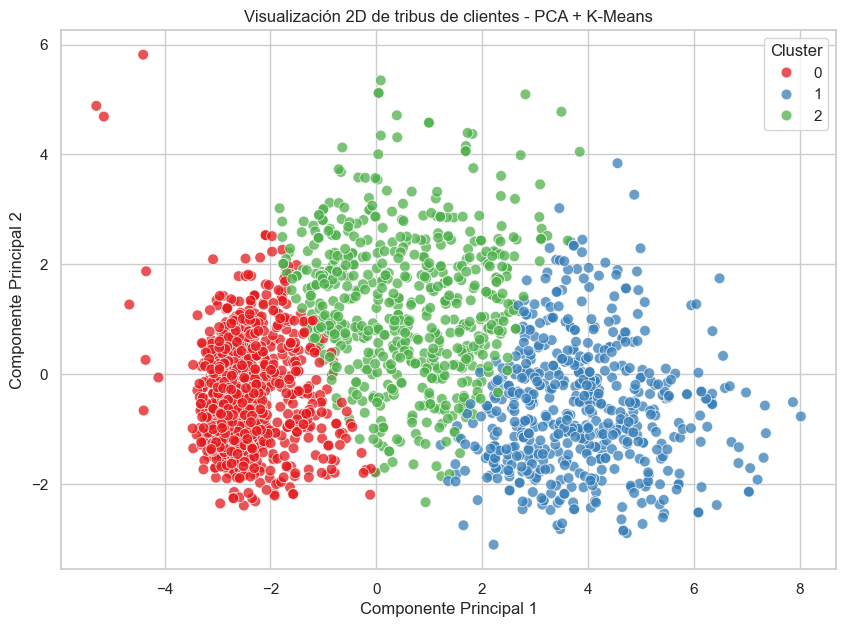

In [33]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_2d_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    alpha=0.75,
    s=60
)

plt.title("Visualización 2D de tribus de clientes - PCA + K-Means")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

c:\Users\valep\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


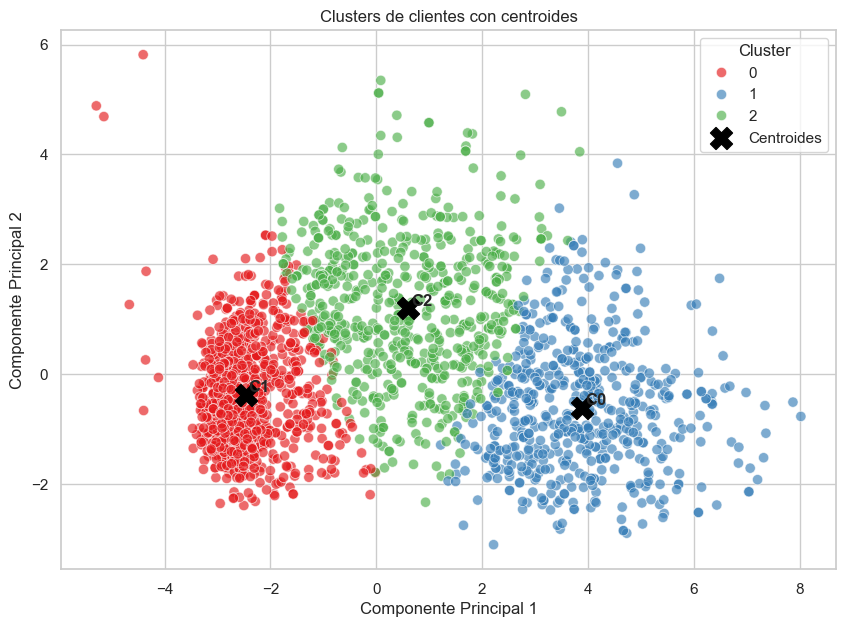

In [37]:
from sklearn.cluster import KMeans

# Crear modelo
final_model = KMeans(n_clusters=3, random_state=42)

# Entrenar
final_model.fit(X_scaled)

# Obtener centroides
centroids_scaled = final_model.cluster_centers_

centroids_pca_2d = pca_2d.transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_pca_2d,
    columns=["PC1", "PC2"]
)

centroids_df["Cluster"] = range(len(centroids_df))

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_2d_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    alpha=0.65,
    s=55
)

plt.scatter(
    centroids_df["PC1"],
    centroids_df["PC2"],
    c="black",
    s=250,
    marker="X",
    label="Centroides"
)

for i, row in centroids_df.iterrows():
    plt.text(
        row["PC1"] + 0.05,
        row["PC2"] + 0.05,
        f"C{i}",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Clusters de clientes con centroides")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

,Cluster,Cantidad_clientes
0,0,1024
1,1,569
2,2,612


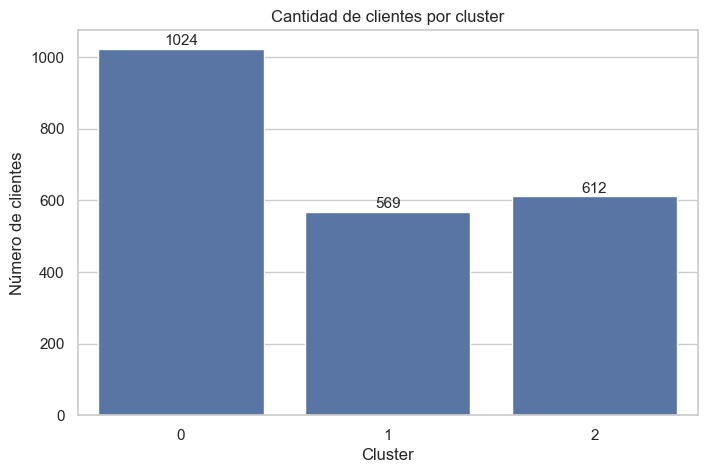

In [38]:
cluster_counts = pd.Series(final_clusters).value_counts().sort_index()

cluster_counts_df = cluster_counts.reset_index()
cluster_counts_df.columns = ["Cluster", "Cantidad_clientes"]

display(cluster_counts_df)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cluster_counts_df,
    x="Cluster",
    y="Cantidad_clientes"
)

for i, row in cluster_counts_df.iterrows():
    plt.text(
        i,
        row["Cantidad_clientes"] + 10,
        str(row["Cantidad_clientes"]),
        ha="center",
        fontsize=11
    )

plt.title("Cantidad de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de clientes")
plt.show()

# FASE 3: PERFILAMIENTO DE TRIBUS

In [39]:
# Usamos df_clean porque conserva valores reales.
df_business = df_clean.copy()

# Agregamos cluster final.
df_business["Cluster"] = final_clusters

print("Distribución de clientes por cluster:")
print(df_business["Cluster"].value_counts().sort_index())

display(df_business.head())

Distribución de clientes por cluster:
Cluster
0    1024
1     569
2     612
Name: count, dtype: int64


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,1,0,0,1529,1441,0,1
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,1,0,0,21,15,0,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,1,0,0,734,692,0,2
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,1,0,0,48,43,0,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,1,407,392,0,2


## VARIABLES DE NEGOCIO PARA PERFILAMIENTO

In [40]:
# Gasto total.
spend_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

spend_columns = [col for col in spend_columns if col in df_business.columns]

if "Total_Spend" not in df_business.columns and len(spend_columns) > 0:
    df_business["Total_Spend"] = df_business[spend_columns].sum(axis=1)

# Compras totales.
purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

purchase_columns = [col for col in purchase_columns if col in df_business.columns]

if "Total_Purchases" not in df_business.columns and len(purchase_columns) > 0:
    df_business["Total_Purchases"] = df_business[purchase_columns].sum(axis=1)

# Ticket promedio.
df_business["Avg_Ticket"] = (
    df_business["Total_Spend"] /
    df_business["Total_Purchases"].replace(0, np.nan)
)

df_business["Avg_Ticket"] = df_business["Avg_Ticket"].fillna(0)

# Participación por canal.
if "NumWebPurchases" in df_business.columns:
    df_business["Web_Purchase_Share"] = (
        df_business["NumWebPurchases"] /
        df_business["Total_Purchases"].replace(0, np.nan)
    ).fillna(0)

if "NumCatalogPurchases" in df_business.columns:
    df_business["Catalog_Purchase_Share"] = (
        df_business["NumCatalogPurchases"] /
        df_business["Total_Purchases"].replace(0, np.nan)
    ).fillna(0)

if "NumStorePurchases" in df_business.columns:
    df_business["Store_Purchase_Share"] = (
        df_business["NumStorePurchases"] /
        df_business["Total_Purchases"].replace(0, np.nan)
    ).fillna(0)

# Campañas aceptadas: evitar doble conteo si existe AcceptedCmpOverall.
# Si el dataset ya trae AcceptedCmpOverall, usamos esa columna porque normalmente
# ya resume cuántas campañas aceptó el cliente. Si además sumáramos AcceptedCmp1,
# AcceptedCmp2, etc., estaríamos duplicando la medición de respuesta a campañas.
if "AcceptedCmpOverall" in df_business.columns:
    df_business["Total_Campaigns_Accepted"] = df_business["AcceptedCmpOverall"]
else:
    campaign_columns = [
        "AcceptedCmp1",
        "AcceptedCmp2",
        "AcceptedCmp3",
        "AcceptedCmp4",
        "AcceptedCmp5",
        "Response"
    ]

    # Filtramos solo las columnas que realmente existan para evitar errores
    # si una versión del dataset no trae todas las campañas.
    campaign_columns = [col for col in campaign_columns if col in df_business.columns]

    # Solo creamos la variable si encontramos al menos una columna de campaña.
    if len(campaign_columns) > 0:
        df_business["Total_Campaigns_Accepted"] = df_business[campaign_columns].sum(axis=1)

# Edad.
if "Age" not in df_business.columns and "Year_Birth" in df_business.columns:
    df_business["Age"] = 2026 - df_business["Year_Birth"]

print("Variables creadas o confirmadas:")
business_cols = [
    "Total_Spend",
    "Total_Purchases",
    "Avg_Ticket",
    "Web_Purchase_Share",
    "Catalog_Purchase_Share",
    "Store_Purchase_Share",
    "Total_Campaigns_Accepted",
    "Age"
]

business_cols = [col for col in business_cols if col in df_business.columns]
print(business_cols)

Variables creadas o confirmadas:
['Total_Spend', 'Total_Purchases', 'Avg_Ticket', 'Web_Purchase_Share', 'Catalog_Purchase_Share', 'Store_Purchase_Share', 'Total_Campaigns_Accepted', 'Age']


### VARIABLES DE NEGOCIO PARA PERFILAMIENTO

In [41]:

# Función auxiliar para sumar columnas existentes
def safe_sum(df, cols):
    cols = [c for c in cols if c in df.columns]
    return df[cols].sum(axis=1) if cols else None

# Función para dividir evitando división por cero
def safe_divide(num, denom):
    return (num / denom.replace(0, np.nan)).fillna(0)


# Gasto total

if "Total_Spend" not in df_business.columns:
    spend = safe_sum(df_business, [
        "MntWines", "MntFruits", "MntMeatProducts",
        "MntFishProducts", "MntSweetProducts", "MntGoldProds"
    ])
    if spend is not None:
        df_business["Total_Spend"] = spend


# Compras totales

if "Total_Purchases" not in df_business.columns:
    purchases = safe_sum(df_business, [
        "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"
    ])
    if purchases is not None:
        df_business["Total_Purchases"] = purchases


# Ticket promedio

df_business["Avg_Ticket"] = safe_divide(
    df_business["Total_Spend"],
    df_business["Total_Purchases"]
)


# Participación por canal

channel_map = {
    "Web_Purchase_Share": "NumWebPurchases",
    "Catalog_Purchase_Share": "NumCatalogPurchases",
    "Store_Purchase_Share": "NumStorePurchases"
}

for new_col, base_col in channel_map.items():
    if base_col in df_business.columns:
        df_business[new_col] = safe_divide(
            df_business[base_col],
            df_business["Total_Purchases"]
        )


# Campañas aceptadas

if "AcceptedCmpOverall" in df_business.columns:
    df_business["Total_Campaigns_Accepted"] = df_business["AcceptedCmpOverall"]
else:
    campaigns = safe_sum(df_business, [
        "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
        "AcceptedCmp4", "AcceptedCmp5", "Response"
    ])
    if campaigns is not None:
        df_business["Total_Campaigns_Accepted"] = campaigns


# Edad

if "Age" not in df_business.columns and "Year_Birth" in df_business.columns:
    df_business["Age"] = 2026 - df_business["Year_Birth"]


# Verificación final

business_cols = [
    "Total_Spend", "Total_Purchases", "Avg_Ticket",
    "Web_Purchase_Share", "Catalog_Purchase_Share",
    "Store_Purchase_Share", "Total_Campaigns_Accepted", "Age"
]

business_cols = [col for col in business_cols if col in df_business.columns]

print("Variables creadas o confirmadas:")
print(business_cols)

Variables creadas o confirmadas:
['Total_Spend', 'Total_Purchases', 'Avg_Ticket', 'Web_Purchase_Share', 'Catalog_Purchase_Share', 'Store_Purchase_Share', 'Total_Campaigns_Accepted', 'Age']


Se realizó la creación de variables derivadas orientadas a capturar el comportamiento de consumo, frecuencia de compra y respuesta a campañas, optimizando el procesamiento mediante funciones reutilizables que garantizan consistencia, manejo de valores faltantes y prevención de errores computacionales.

In [42]:
profile_columns = [
    "Income",
    "Age",
    "Recency",
    "Total_Spend",
    "Total_Purchases",
    "Avg_Ticket",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Web_Purchase_Share",
    "Catalog_Purchase_Share",
    "Store_Purchase_Share",
    "Total_Campaigns_Accepted"
]

profile_columns = [col for col in profile_columns if col in df_business.columns]

cluster_profile = df_business.groupby("Cluster")[profile_columns].mean()

cluster_profile["Cantidad_Clientes"] = df_business.groupby("Cluster").size()

cluster_profile["Porcentaje_Clientes"] = (
    cluster_profile["Cantidad_Clientes"] / len(df_business) * 100
)

cluster_profile = cluster_profile.round(2)

display(cluster_profile.T)

Cluster,0,1,2
Income,34595.08,76078.09,57374.06
Age,48.47,51.65,54.97
Recency,49.48,50.42,46.91
Total_Spend,96.71,1419.42,704.83
Total_Purchases,5.88,19.73,17.11
Avg_Ticket,14.49,74.96,40.87
MntWines,42.08,641.74,436.04
MntFruits,4.89,69.49,22.34
MntMeatProducts,22.48,457.38,132.76
MntFishProducts,6.86,101.33,30.34


### PERFIL RELATIVO VS PROMEDIO GENERAL

In [43]:
overall_mean = df_business[profile_columns].mean()

cluster_relative = (
    df_business.groupby("Cluster")[profile_columns].mean() /
    overall_mean
)

cluster_relative = cluster_relative.round(2)

display(cluster_relative.T)

Cluster,0,1,2
Income,0.67,1.47,1.11
Age,0.95,1.01,1.08
Recency,1.01,1.03,0.96
Total_Spend,0.16,2.34,1.16
Total_Purchases,0.47,1.57,1.36
Avg_Ticket,0.39,2.00,1.09
MntWines,0.14,2.10,1.42
MntFruits,0.19,2.63,0.85
MntMeatProducts,0.14,2.77,0.80
MntFishProducts,0.18,2.68,0.80


### HEATMAP DEL PERFIL RELATIVO

<Axes: ylabel='Cluster'>

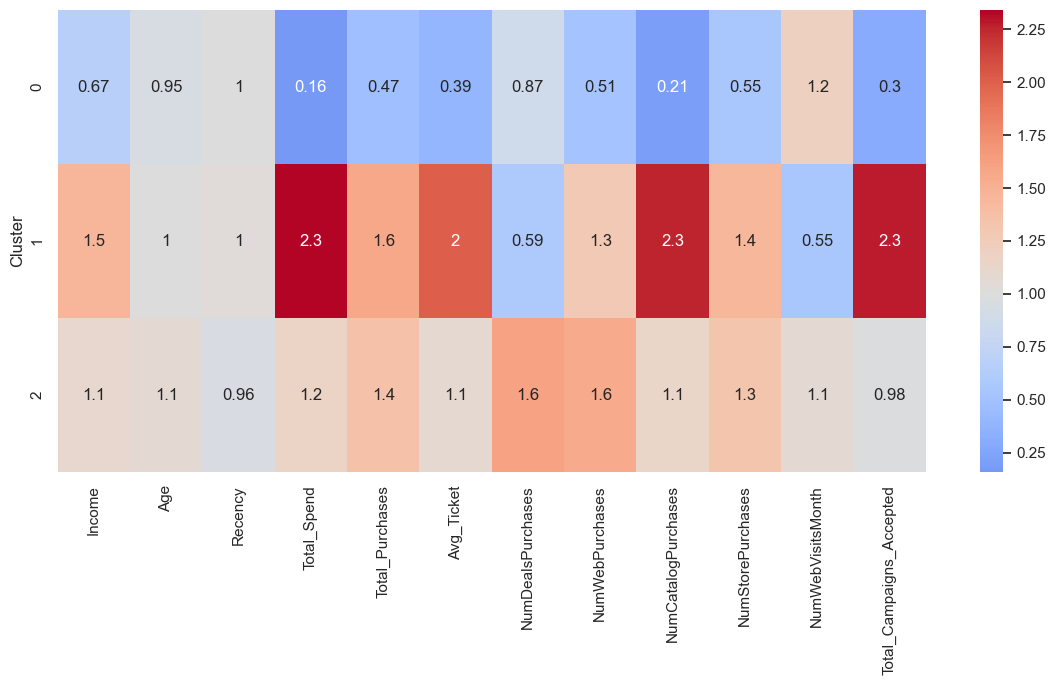

In [44]:

heatmap_columns = [
    "Income",
    "Age",
    "Recency",
    "Total_Spend",
    "Total_Purchases",
    "Avg_Ticket",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Total_Campaigns_Accepted"
]

heatmap_columns = [col for col in heatmap_columns if col in cluster_relative.columns]

plt.figure(figsize=(14, 6))

sns.heatmap(
    cluster_relative[heatmap_columns],
    annot=True,
    cmap="coolwarm",
    center=1
)

## TABLA RESUMEN DE TRIBUS

In [45]:
tribe_summary_cols = [
    "Cantidad_Clientes",
    "Porcentaje_Clientes",
    "Income",
    "Age",
    "Recency",
    "Total_Spend",
    "Total_Purchases",
    "Avg_Ticket",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Total_Campaigns_Accepted"
]

tribe_summary_cols = [
    col for col in tribe_summary_cols
    if col in cluster_profile.columns
]

tribe_summary = cluster_profile[tribe_summary_cols].copy()

display(tribe_summary)

,Cantidad_Clientes,Porcentaje_Clientes,Income,Age,Recency,Total_Spend,Total_Purchases,Avg_Ticket,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted
Cluster,,,,,,,,,,,,,,
0,1024,46.44,34595.08,48.47,49.48,96.71,5.88,14.49,2.01,2.09,0.56,3.22,6.42,0.09
1,569,25.80,76078.09,51.65,50.42,1419.42,19.73,74.96,1.36,5.28,5.99,8.46,2.93,0.68
2,612,27.76,57374.06,54.97,46.91,704.83,17.11,40.87,3.73,6.36,3.03,7.72,5.75,0.29


### RANKINGS PARA INTERPRETAR TRIBUS

In [46]:

high_is_good = [
    "Income",
    "Total_Spend",
    "Total_Purchases",
    "Avg_Ticket",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Total_Campaigns_Accepted"
]

high_is_alert = [
    "Recency",
    "NumWebVisitsMonth",
    "NumDealsPurchases"
]

high_is_good = [col for col in high_is_good if col in cluster_profile.columns]
high_is_alert = [col for col in high_is_alert if col in cluster_profile.columns]

print("Clusters líderes en variables positivas:")
for col in high_is_good:
    best_cluster = cluster_profile[col].idxmax()
    best_value = cluster_profile.loc[best_cluster, col]
    print(f"- Mayor {col}: Cluster {best_cluster} con {best_value}")

print("\nClusters líderes en variables de alerta o interpretación especial:")
for col in high_is_alert:
    top_cluster = cluster_profile[col].idxmax()
    top_value = cluster_profile.loc[top_cluster, col]
    print(f"- Mayor {col}: Cluster {top_cluster} con {top_value}")

if "Recency" in cluster_profile.columns:
    recent_cluster = cluster_profile["Recency"].idxmin()
    recent_value = cluster_profile.loc[recent_cluster, "Recency"]
    print(f"\nCluster con menor Recency: Cluster {recent_cluster} con {recent_value}")

Clusters líderes en variables positivas:
- Mayor Income: Cluster 1 con 76078.09
- Mayor Total_Spend: Cluster 1 con 1419.42
- Mayor Total_Purchases: Cluster 1 con 19.73
- Mayor Avg_Ticket: Cluster 1 con 74.96
- Mayor NumWebPurchases: Cluster 2 con 6.36
- Mayor NumCatalogPurchases: Cluster 1 con 5.99
- Mayor NumStorePurchases: Cluster 1 con 8.46
- Mayor Total_Campaigns_Accepted: Cluster 1 con 0.68

Clusters líderes en variables de alerta o interpretación especial:
- Mayor Recency: Cluster 1 con 50.42
- Mayor NumWebVisitsMonth: Cluster 0 con 6.42
- Mayor NumDealsPurchases: Cluster 2 con 3.73

Cluster con menor Recency: Cluster 2 con 46.91



### GRÁFICOS DE PERFILAMIENTO DE TRIBUS


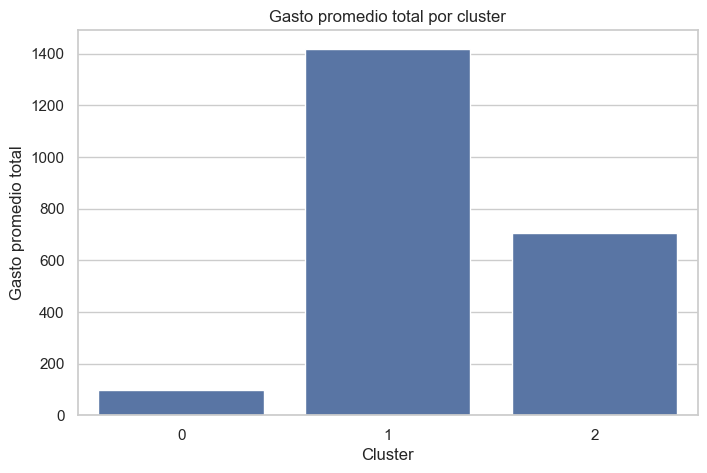

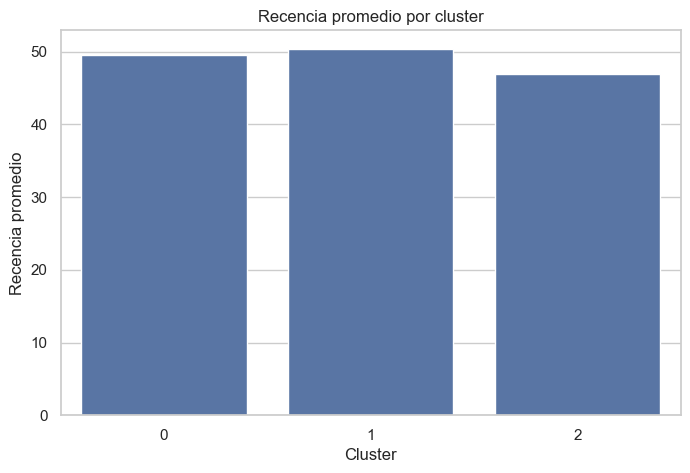

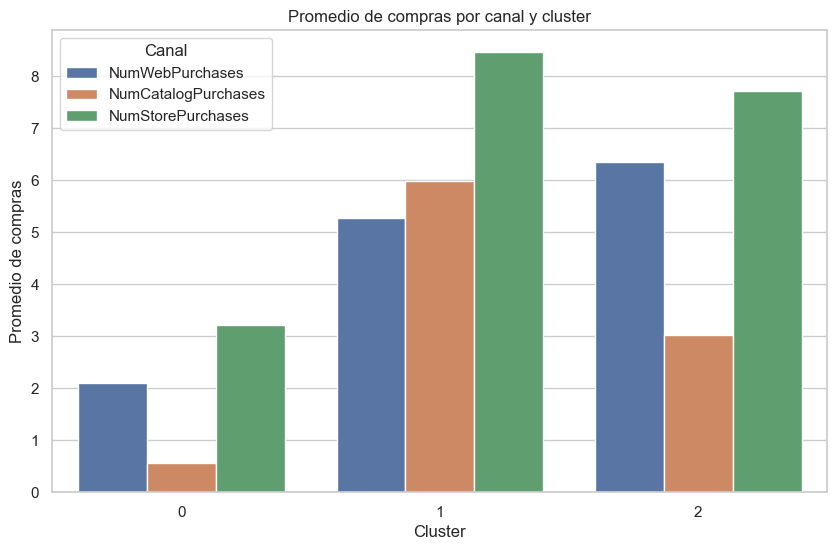

In [47]:

# Gasto promedio por cluster.
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_business,
    x="Cluster",
    y="Total_Spend",
    estimator=np.mean,
    errorbar=None
)
plt.title("Gasto promedio total por cluster")
plt.xlabel("Cluster")
plt.ylabel("Gasto promedio total")
plt.show()

# Recencia promedio por cluster.
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_business,
    x="Cluster",
    y="Recency",
    estimator=np.mean,
    errorbar=None
)
plt.title("Recencia promedio por cluster")
plt.xlabel("Cluster")
plt.ylabel("Recencia promedio")
plt.show()

# Canales de compra.
channel_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_columns = [col for col in channel_columns if col in df_business.columns]

channel_profile = (
    df_business
    .groupby("Cluster")[channel_columns]
    .mean()
    .reset_index()
)

channel_profile_long = channel_profile.melt(
    id_vars="Cluster",
    value_vars=channel_columns,
    var_name="Canal",
    value_name="Promedio_Compras"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=channel_profile_long,
    x="Cluster",
    y="Promedio_Compras",
    hue="Canal"
)
plt.title("Promedio de compras por canal y cluster")
plt.xlabel("Cluster")
plt.ylabel("Promedio de compras")
plt.legend(title="Canal")
plt.show()


### ASIGNACIÓN DE NOMBRES COMERCIALES


In [48]:


tribe_names = {
    0: "Los Exploradores de Bajo Consumo",
    1: "Los VIP Omnicanal",
    2: "Los Cazadores de Ofertas Activos"
}

df_business["Tribu"] = df_business["Cluster"].map(tribe_names)

tribe_summary_named = tribe_summary.copy()
tribe_summary_named["Nombre_Comercial"] = tribe_summary_named.index.map(tribe_names)

cols_order = ["Nombre_Comercial"] + [
    col for col in tribe_summary_named.columns
    if col != "Nombre_Comercial"
]

tribe_summary_named = tribe_summary_named[cols_order]

display(tribe_summary_named)

,Nombre_Comercial,Cantidad_Clientes,Porcentaje_Clientes,Income,Age,Recency,Total_Spend,Total_Purchases,Avg_Ticket,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted
Cluster,,,,,,,,,,,,,,,
0,Los Exploradores de Bajo Consumo,1024,46.44,34595.08,48.47,49.48,96.71,5.88,14.49,2.01,2.09,0.56,3.22,6.42,0.09
1,Los VIP Omnicanal,569,25.80,76078.09,51.65,50.42,1419.42,19.73,74.96,1.36,5.28,5.99,8.46,2.93,0.68
2,Los Cazadores de Ofertas Activos,612,27.76,57374.06,54.97,46.91,704.83,17.11,40.87,3.73,6.36,3.03,7.72,5.75,0.29


## Bautizo de tribus

Con base en los promedios reales de cada cluster, se asignaron nombres comerciales que permiten explicar los segmentos en lenguaje de negocio. El objetivo de este paso es transformar etiquetas técnicas como `Cluster 0`, `Cluster 1` y `Cluster 2` en tribus comprensibles y accionables para una estrategia de marketing.

El **Cluster 0** fue denominado **“Los Exploradores de Bajo Consumo”**. Este grupo representa el 46.44% de la base, con 1024 clientes. Presenta el menor ingreso promedio, 34595.08, el menor gasto total promedio, 96.71, y solo 5.88 compras promedio. Sin embargo, registra 6.42 visitas web mensuales, lo que sugiere interacción digital con baja conversión.

El **Cluster 1** fue denominado **“Los VIP Omnicanal”**. Este grupo representa el 25.80% de la base, con 569 clientes. Es la tribu de mayor valor económico, con ingreso promedio de 76078.09, gasto total promedio de 1419.42, ticket promedio de 74.96 y 19.73 compras promedio. Además, combina compras en tienda, catálogo y web.

El **Cluster 2** fue denominado **“Los Cazadores de Ofertas Activos”**. Este grupo representa el 27.76% de la base, con 612 clientes. Tiene ingreso medio-alto, gasto total promedio de 704.83 y 17.11 compras promedio. Destaca por el mayor número de compras con descuento, 3.73, y el mayor promedio de compras web, 6.36.


### TABLA DE CAMPAÑAS DE MARKETING

In [49]:

marketing_campaigns = pd.DataFrame({
    "Campaña": [
        "Programa VIP Omnicanal",
        "Ofertas Inteligentes para Clientes Activos",
        "Conversión de Exploradores Digitales"
    ],
    "Tribu_objetivo": [
        "Los VIP Omnicanal",
        "Los Cazadores de Ofertas Activos",
        "Los Exploradores de Bajo Consumo"
    ],
    "Objetivo_de_negocio": [
        "Fidelizar y aumentar el valor de los clientes más rentables.",
        "Estimular compras recurrentes aprovechando su sensibilidad a descuentos.",
        "Convertir clientes de baja compra en compradores más frecuentes."
    ],
    "Accion_recomendada": [
        "Crear un programa premium con beneficios exclusivos, bundles de alto valor, preventas y recompensas por compras en múltiples canales.",
        "Enviar promociones personalizadas, cupones por tiempo limitado y bundles con descuento en productos de alta rotación.",
        "Implementar campañas digitales de bajo costo con recomendaciones simples, descuentos de primera compra o envío gratis condicionado a una compra mínima."
    ],
    "Justificacion_con_datos": [
        "Esta tribu tiene el mayor ingreso promedio, 76078.09, el mayor gasto total, 1419.42, el mayor ticket promedio, 74.96, y la mayor frecuencia de compra, 19.73 compras.",
        "Esta tribu tiene 17.11 compras promedio, 704.83 de gasto total y el mayor número de compras con descuento, 3.73, además del mayor promedio de compras web, 6.36.",
        "Esta tribu representa el 46.44% de la base, pero tiene el menor gasto total, 96.71, y solo 5.88 compras promedio. Sin embargo, registra 6.42 visitas web mensuales, lo que indica oportunidad de conversión."
    ]
})

display(marketing_campaigns)

,Campaña,Tribu_objetivo,Objetivo_de_negocio,Accion_recomendada,Justificacion_con_datos
0,Programa VIP Omnicanal,Los VIP Omnicanal,Fidelizar y aumentar el valor de los clientes ...,Crear un programa premium con beneficios exclu...,"Esta tribu tiene el mayor ingreso promedio, 76..."
1,Ofertas Inteligentes para Clientes Activos,Los Cazadores de Ofertas Activos,Estimular compras recurrentes aprovechando su ...,"Enviar promociones personalizadas, cupones por...","Esta tribu tiene 17.11 compras promedio, 704.8..."
2,Conversión de Exploradores Digitales,Los Exploradores de Bajo Consumo,Convertir clientes de baja compra en comprador...,Implementar campañas digitales de bajo costo c...,"Esta tribu representa el 46.44% de la base, pe..."


## Estrategia de marketing

Las campañas propuestas se diseñan a partir de las diferencias reales observadas entre las tribus. Cada recomendación conecta un hallazgo numérico con una decisión comercial concreta.

### Campaña 1: Programa VIP Omnicanal

**Tribu objetivo:** Los VIP Omnicanal.

**Hallazgo numérico:** Esta tribu tiene el mayor ingreso promedio, 76078.09, el mayor gasto total promedio, 1419.42, el mayor ticket promedio, 74.96, y la mayor frecuencia de compra, con 19.73 compras promedio.

**Acción recomendada:** Crear un programa premium con beneficios exclusivos, bundles de alto valor, preventas, recompensas por compras multicanal y atención preferencial.

**Justificación de negocio:** Esta tribu ya genera alto valor para la empresa. Por ello, la prioridad no debe ser aplicar descuentos agresivos, sino fortalecer la fidelización, la retención, la recompra y el aumento del ticket promedio.

### Campaña 2: Ofertas Inteligentes para Clientes Activos

**Tribu objetivo:** Los Cazadores de Ofertas Activos.

**Hallazgo numérico:** Esta tribu tiene 17.11 compras promedio, gasto total de 704.83 y el mayor número de compras con descuento, 3.73. También registra el mayor promedio de compras web, con 6.36.

**Acción recomendada:** Diseñar promociones personalizadas, cupones por tiempo limitado, bundles con descuento y campañas digitales segmentadas según categorías de mayor consumo.

**Justificación de negocio:** Estos clientes compran con frecuencia y muestran sensibilidad a promociones. Una estrategia de descuentos controlados puede aumentar frecuencia y gasto sin sacrificar excesivamente el margen.

### Campaña 3: Conversión de Exploradores Digitales

**Tribu objetivo:** Los Exploradores de Bajo Consumo.

**Hallazgo numérico:** Esta tribu representa el 46.44% de la base, pero tiene el menor gasto total promedio, 96.71, y solo 5.88 compras promedio. A pesar de ello, registra 6.42 visitas web mensuales.

**Acción recomendada:** Implementar campañas digitales de conversión con recomendaciones simples, descuentos de primera compra, envío gratis condicionado a compra mínima y recordatorios personalizados.

**Justificación de negocio:** Aunque esta tribu tiene bajo gasto, su tamaño y su actividad web indican una oportunidad de conversión. La empresa puede generar crecimiento si convierte una parte de estos visitantes en compradores recurrentes.

In [50]:
display(tribe_summary)

,Cantidad_Clientes,Porcentaje_Clientes,Income,Age,Recency,Total_Spend,Total_Purchases,Avg_Ticket,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Campaigns_Accepted
Cluster,,,,,,,,,,,,,,
0,1024,46.44,34595.08,48.47,49.48,96.71,5.88,14.49,2.01,2.09,0.56,3.22,6.42,0.09
1,569,25.80,76078.09,51.65,50.42,1419.42,19.73,74.96,1.36,5.28,5.99,8.46,2.93,0.68
2,612,27.76,57374.06,54.97,46.91,704.83,17.11,40.87,3.73,6.36,3.03,7.72,5.75,0.29


## Conclusiones finales

El proyecto permitió identificar tres tribus de clientes a partir de variables de ingreso, gasto, recencia, frecuencia y canales de compra. El proceso incluyó limpieza, análisis exploratorio, laboratorio de escalamiento y comparación de algoritmos de clustering.

El modelo seleccionado fue **K-Means con K = 3**, porque ofreció el mejor equilibrio entre desempeño técnico, tamaños de cluster adecuados e interpretabilidad comercial. Aunque K = 2 obtuvo una silueta más alta, se consideró una segmentación demasiado general para diseñar tres campañas diferenciadas.

La segmentación final diferenció tres grupos relevantes: **Los Exploradores de Bajo Consumo**, **Los VIP Omnicanal** y **Los Cazadores de Ofertas Activos**. Cada tribu presenta patrones distintos de ingreso, gasto, frecuencia, canal de compra y respuesta comercial.

Desde el punto de vista de negocio, los resultados permiten pasar de una estrategia homogénea a una estrategia segmentada: fidelizar a los clientes VIP, incentivar con promociones controladas a los cazadores de ofertas y convertir a los exploradores digitales de bajo consumo en compradores más frecuentes.